In [ ]:
c
# ---------- shared constants (match notebooks/all_code2.py) ----------
PATCH_SIZE = 256
SCALE_M = 10
LOOKBACK = 3

MODEL_DIR = "/content/drive/MyDrive/Data_experiment_shoreline/models"
LOG_DIR = "/content/drive/MyDrive/Data_experiment_shoreline/logs"
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)
print("MODEL_DIR:", MODEL_DIR)
print("LOG_DIR  :", LOG_DIR)


EE initialized | gen-lang-client-0412358476
MODEL_DIR: /content/drive/MyDrive/Data_experiment_shoreline/models
LOG_DIR  : /content/drive/MyDrive/Data_experiment_shoreline/logs


In [8]:
# ============================================================
# CELL 2 — Locate offline bundles on Drive
#   Sentinel-2 : Data_experiment_shoreline/offline_256_adaptive.zip (8 AOI, S1/S2/S3, 2018-2025)
#   Landsat    : shoreline_kemujan/landsat_offline.zip             (8 AOI, L1/L2,    2008-2018)
# ============================================================
import os

SENTINEL_ZIP = "/content/drive/MyDrive/Data_experiment_shoreline/offline_256_adaptive.zip"
LANDSAT_ZIP  = "/content/drive/MyDrive/shoreline_kemujan/landsat_offline.zip"

for label, path in [("Sentinel-2", SENTINEL_ZIP), ("Landsat", LANDSAT_ZIP)]:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"{label} bundle tidak ditemukan di {path} — cek nama file/folder di Drive "
            f"(lihat Drive > Data_experiment_shoreline dan Drive > shoreline_kemujan)."
        )
    size_mb = os.path.getsize(path) / 1e6
    print(f"[{label}] OK — {path} ({size_mb:.1f} MB)")


[Sentinel-2] OK — /content/drive/MyDrive/Data_experiment_shoreline/offline_256_adaptive.zip (0.2 MB)
[Landsat] OK — /content/drive/MyDrive/shoreline_kemujan/landsat_offline.zip (0.2 MB)


In [9]:
# ============================================================
# CELL 3 — Unpack both bundles + load masks/manifest
# ============================================================
import os
import json
import zipfile
import numpy as np

SENTINEL_DIR = "/content/bundle_sentinel"
LANDSAT_DIR  = "/content/bundle_landsat"

with zipfile.ZipFile(SENTINEL_ZIP, "r") as z:
    z.extractall(SENTINEL_DIR)
with zipfile.ZipFile(LANDSAT_ZIP, "r") as z:
    z.extractall(LANDSAT_DIR)


def _find_bundle_root(extract_dir):
    """zip mungkin extract langsung isi bundle, atau 1 subfolder pembungkus
    (mis. offline_256_adaptive/) -- deteksi otomatis dgn cari manifest.json."""
    if os.path.exists(os.path.join(extract_dir, "manifest.json")):
        return extract_dir
    for entry in os.listdir(extract_dir):
        sub = os.path.join(extract_dir, entry)
        if os.path.isdir(sub) and os.path.exists(os.path.join(sub, "manifest.json")):
            return sub
    raise FileNotFoundError(f"manifest.json tidak ketemu di bawah {extract_dir}")


def load_offline(bundle_dir, strip_suffix=None):
    """strip_suffix: bundle Landsat nyimpen npz-nya sbg '{aoi}_landsat_masks.npz'
    (lihat export_offline_landsat di all_code2.py), jadi strip '_masks.npz' polos
    bakal nyisain 'Titik_02_landsat' -- itu TIDAK PERNAH match 'Titik_02' punya
    Sentinel di merge Cell 5. Pass strip_suffix='_landsat' biar nama AOI balik
    normal ('Titik_NN') dan bisa di-join lintas sensor."""
    with open(os.path.join(bundle_dir, "manifest.json")) as f:
        manifest = json.load(f)
    masks = {}
    for fn in os.listdir(bundle_dir):
        if not fn.endswith("_masks.npz"):
            continue
        nama = fn.replace("_masks.npz", "")
        if strip_suffix and nama.endswith(strip_suffix):
            nama = nama[: -len(strip_suffix)]
        z = np.load(os.path.join(bundle_dir, fn))
        masks[nama] = {(int(k.split("_")[0]), k.split("_")[1]): z[k] for k in z.files}
    print(f"Loaded {len(masks)} AOI dari {bundle_dir}")
    return masks, manifest


SENTINEL_BUNDLE_DIR = _find_bundle_root(SENTINEL_DIR)
LANDSAT_BUNDLE_DIR  = _find_bundle_root(LANDSAT_DIR)

masks_sentinel, manifest_sentinel = load_offline(SENTINEL_BUNDLE_DIR)
masks_landsat,  manifest_landsat  = load_offline(LANDSAT_BUNDLE_DIR, strip_suffix="_landsat")

# Titik_19 sengaja dikeluarkan dari training set (all_code2.py:
# "masks.pop('Titik_19', None)") -- exclude di sini juga, sebelum validasi/merge.
if "Titik_19" in masks_sentinel:
    masks_sentinel.pop("Titik_19")
    manifest_sentinel.get("aoi", {}).pop("Titik_19", None)
    print("Titik_19 dikeluarkan dari masks_sentinel (dikecualikan dari training set).")

print("Sentinel AOI:", sorted(masks_sentinel.keys()))
print("Landsat  AOI:", sorted(masks_landsat.keys()))

_common = sorted(set(masks_sentinel.keys()) & set(masks_landsat.keys()))
_only_sentinel = sorted(set(masks_sentinel.keys()) - set(masks_landsat.keys()))
_only_landsat = sorted(set(masks_landsat.keys()) - set(masks_sentinel.keys()))
print(f"\nAOI di KEDUA bundle: {_common} ({len(_common)})")
if _only_sentinel:
    print(f"AOI HANYA di Sentinel (Landsat tidak ada): {_only_sentinel}")
if _only_landsat:
    print(f"AOI HANYA di Landsat (Sentinel tidak ada): {_only_landsat}")


Loaded 9 AOI dari /content/bundle_sentinel/offline_256_adaptive
Loaded 8 AOI dari /content/bundle_landsat
Titik_19 dikeluarkan dari masks_sentinel (dikecualikan dari training set).
Sentinel AOI: ['Titik_02', 'Titik_04', 'Titik_05', 'Titik_06', 'Titik_07', 'Titik_09', 'Titik_10', 'Titik_11']
Landsat  AOI: ['Titik_02', 'Titik_04', 'Titik_05', 'Titik_06', 'Titik_07', 'Titik_09', 'Titik_10', 'Titik_11']

AOI di KEDUA bundle: ['Titik_02', 'Titik_04', 'Titik_05', 'Titik_06', 'Titik_07', 'Titik_09', 'Titik_10', 'Titik_11'] (8)


frame_df: 359 frame total (176 landsat, 183 sentinel)

=== Dimension check (target semua == 256x256) ===
sensor    height  width
landsat   256     256      176
sentinel  256     256      183
dtype: int64
OK -- semua 359 frame sudah 256x256, tidak ada yang perlu di-fix.

=== Univariate: water_fraction (fraksi pixel air per frame) ===
count    359.000000
mean       0.464792
std        0.291490
min        0.000000
25%        0.252998
50%        0.508606
75%        0.705124
max        1.000000
Name: water_fraction, dtype: float64

Per sensor:
          count      mean       std  min       25%       50%       75%  \
sensor                                                                   
landsat   176.0  0.397060  0.349159  0.0  0.013588  0.338791  0.717781   
sentinel  183.0  0.529933  0.202991  0.0  0.393906  0.531830  0.667656   

               max  
sensor              
landsat   1.000000  
sentinel  0.821915  


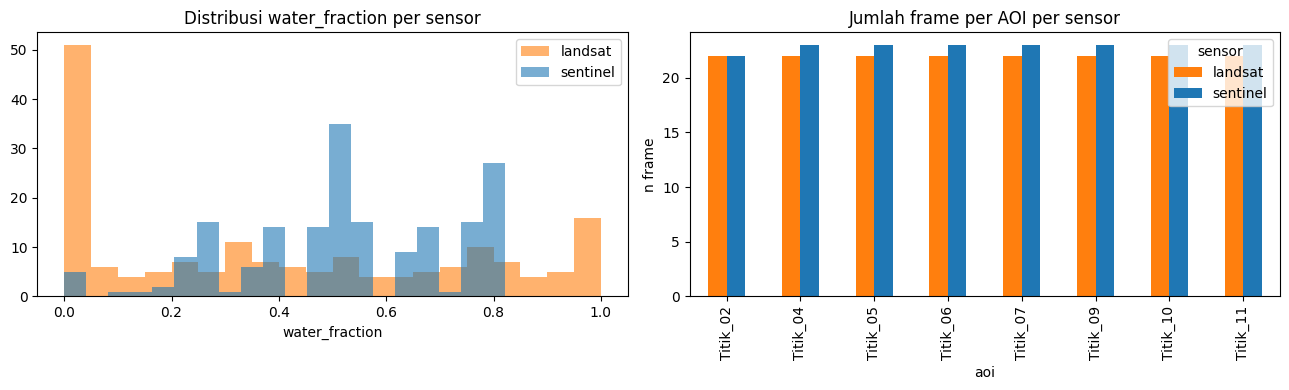


=== Multivariate: cek seam Landsat->Sentinel & kelengkapan data ===


/tmp/ipykernel_785/3779782475.py:116: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_box, labels=labels_box)


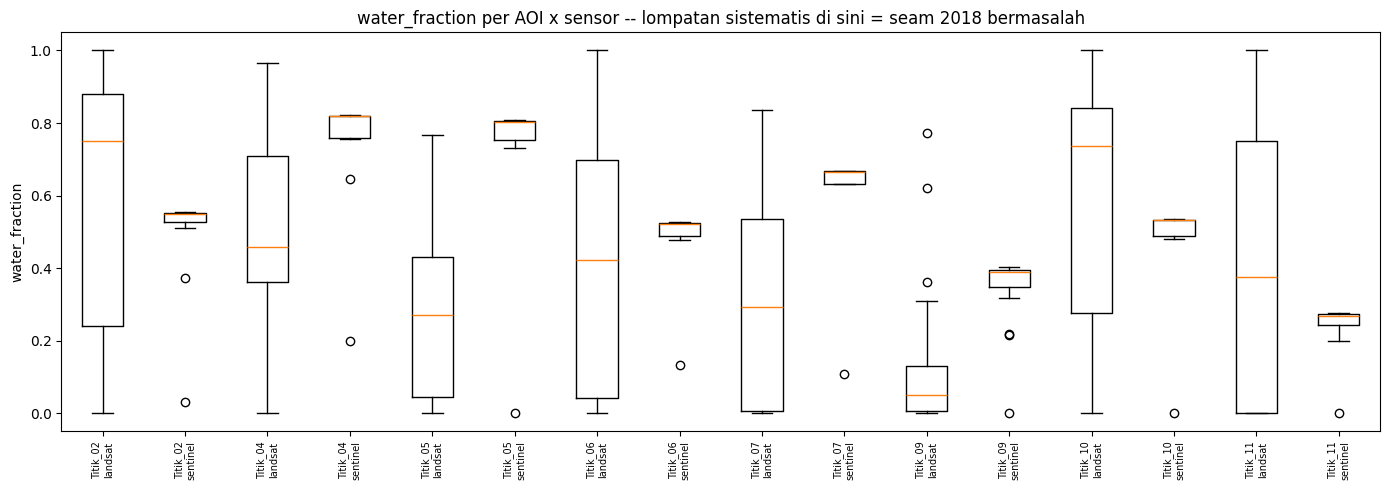

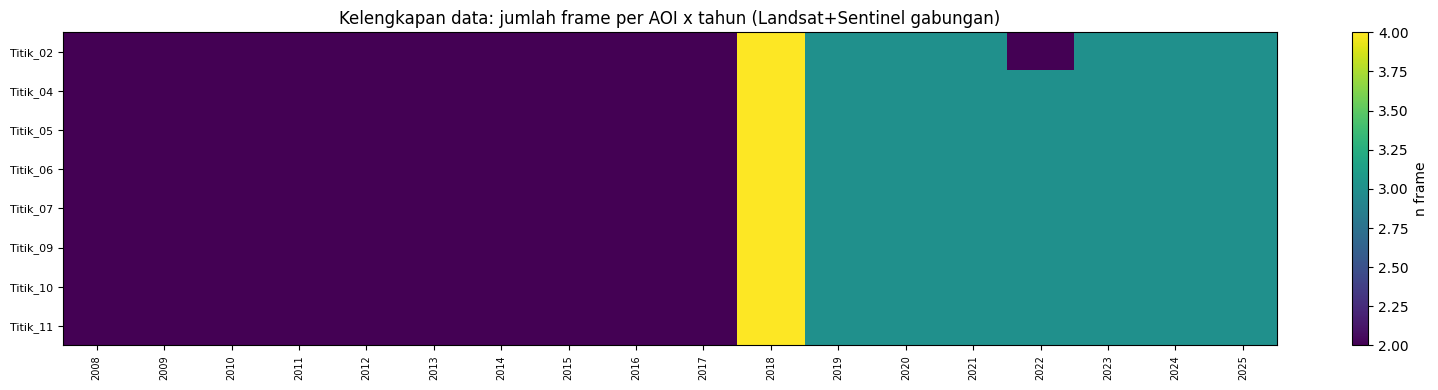


Korelasi water_fraction vs n_scene vs year:
                water_fraction   n_scene      year
water_fraction        1.000000 -0.045867  0.197240
n_scene              -0.045867  1.000000  0.551656
year                  0.197240  0.551656  1.000000

=== RINGKASAN VALIDASI ===
359/359 frame di 256x256 (setelah 0 auto-fix).
⚠️  Seam discontinuity terdeteksi di tahun 2018 untuk: [('Titik_02', 0.53), ('Titik_06', 0.257), ('Titik_10', 0.508), ('Titik_11', 0.459)] (|Δ water_fraction| > 0.15) -- cek threshold Otsu masing2 sensor sebelum percaya hasil merge di Cell 5.


In [10]:
# ============================================================
# CELL 4 — Dimension validation + granular per-frame analytics
#   (univariate + multivariate), run BEFORE combining (next cell).
#
# Why here: the two Drive bundles come from different pipelines (Landsat 30m
# resampled vs Sentinel native 10m) and were flagged as differently sized --
# better to catch a shape mismatch or a systematic seam between sensors HERE,
# as a readable table/plot, than as a confusing np.stack() error (or worse,
# a silently distorted merged timeline) further down the notebook.
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _fit_patch(mask_arr, patch_size=PATCH_SIZE):
    """Center-crop/pad to (patch_size, patch_size). Same fix used in the
    Landsat export step of all_code2.py -- reused, not reimplemented."""
    t = patch_size
    h, w = mask_arr.shape
    if h > t:
        mask_arr = mask_arr[(h - t) // 2:(h - t) // 2 + t, :]
    if w > t:
        mask_arr = mask_arr[:, (w - t) // 2:(w - t) // 2 + t]
    h, w = mask_arr.shape
    if h < t or w < t:
        pad = np.zeros((t, t), dtype=mask_arr.dtype)
        pad[:h, :w] = mask_arr
        mask_arr = pad
    return mask_arr


def _frame_rows(masks, manifest, sensor):
    rows = []
    manifest_aoi = manifest.get("aoi", {})
    for aoi, frames in masks.items():
        frame_meta = manifest_aoi.get(aoi, {}).get("frames", {})
        for (yr, season), arr in frames.items():
            n_scene = frame_meta.get(f"{yr}_{season}")
            n_scene = n_scene if isinstance(n_scene, (int, float)) else np.nan
            rows.append({
                "aoi": aoi, "sensor": sensor, "year": yr, "season": season,
                "height": arr.shape[0], "width": arr.shape[1],
                "water_fraction": float(arr.mean()), "n_scene": n_scene,
            })
    return rows


rows = (_frame_rows(masks_landsat, manifest_landsat, "landsat")
        + _frame_rows(masks_sentinel, manifest_sentinel, "sentinel"))
frame_df = pd.DataFrame(rows)
print(f"frame_df: {len(frame_df)} frame total "
      f"({(frame_df.sensor == 'landsat').sum()} landsat, {(frame_df.sensor == 'sentinel').sum()} sentinel)")

# ============================================================
# 1. DIMENSION VALIDATION
# ============================================================
print(f"\n=== Dimension check (target semua == {PATCH_SIZE}x{PATCH_SIZE}) ===")
print(frame_df.groupby(["sensor", "height", "width"]).size())

mismatch = frame_df[(frame_df.height != PATCH_SIZE) | (frame_df.width != PATCH_SIZE)]
fix_log = []
if len(mismatch):
    print(f"\n{len(mismatch)} frame BUKAN {PATCH_SIZE}x{PATCH_SIZE} -- auto-fix (center-crop/pad):")
    for _, row in mismatch.iterrows():
        masks_dict = masks_landsat if row.sensor == "landsat" else masks_sentinel
        key = (row.year, row.season)
        arr = masks_dict[row.aoi][key]
        old_shape = arr.shape
        fixed = _fit_patch(arr, PATCH_SIZE)
        if fixed.shape != (PATCH_SIZE, PATCH_SIZE):
            raise ValueError(
                f"Gagal fix {row.aoi} {row.sensor} {row.year}_{row.season}: shape {old_shape} "
                f"tidak bisa dikoreksi ke {PATCH_SIZE}x{PATCH_SIZE} -- cek file sumbernya, jangan dipaksa."
            )
        masks_dict[row.aoi][key] = fixed
        fix_log.append((row.aoi, row.sensor, row.year, row.season, old_shape, fixed.shape))
        print(f"  [{row.aoi}] {row.sensor} {row.year}_{row.season}: {old_shape} -> {fixed.shape}")
    frame_df.loc[mismatch.index, ["height", "width"]] = PATCH_SIZE
else:
    print(f"OK -- semua {len(frame_df)} frame sudah {PATCH_SIZE}x{PATCH_SIZE}, tidak ada yang perlu di-fix.")

# ============================================================
# 2. UNIVARIATE ANALYTICS
# ============================================================
print("\n=== Univariate: water_fraction (fraksi pixel air per frame) ===")
print(frame_df["water_fraction"].describe())
print("\nPer sensor:")
print(frame_df.groupby("sensor")["water_fraction"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for sensor, color in [("landsat", "tab:orange"), ("sentinel", "tab:blue")]:
    sub = frame_df[frame_df.sensor == sensor]
    axes[0].hist(sub["water_fraction"], bins=20, alpha=0.6, label=sensor, color=color)
axes[0].set_title("Distribusi water_fraction per sensor")
axes[0].set_xlabel("water_fraction"); axes[0].legend()

frame_counts = frame_df.groupby(["aoi", "sensor"]).size().unstack(fill_value=0)
frame_counts.plot(kind="bar", ax=axes[1], color=["tab:orange", "tab:blue"])
axes[1].set_title("Jumlah frame per AOI per sensor"); axes[1].set_ylabel("n frame")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "eda_univariate_water_fraction.png"), dpi=120)
plt.show()

# ============================================================
# 3. MULTIVARIATE ANALYTICS
# ============================================================
print("\n=== Multivariate: cek seam Landsat->Sentinel & kelengkapan data ===")
aoi_order = sorted(frame_df["aoi"].unique())

fig, ax = plt.subplots(figsize=(14, 5))
data_box = [frame_df[(frame_df.aoi == a) & (frame_df.sensor == s)]["water_fraction"].values
            for a in aoi_order for s in ("landsat", "sentinel")]
labels_box = [f"{a}\n{s}" for a in aoi_order for s in ("landsat", "sentinel")]
ax.boxplot(data_box, labels=labels_box)
ax.set_xticklabels(labels_box, rotation=90, fontsize=7)
ax.set_title("water_fraction per AOI x sensor -- lompatan sistematis di sini = seam 2018 bermasalah")
ax.set_ylabel("water_fraction")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "eda_multivariate_seam_check.png"), dpi=120)
plt.show()

completeness = frame_df.pivot_table(index="aoi", columns="year", values="water_fraction",
                                     aggfunc="count", fill_value=0)
fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(completeness.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(completeness.columns))); ax.set_xticklabels(completeness.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(completeness.index))); ax.set_yticklabels(completeness.index, fontsize=8)
ax.set_title("Kelengkapan data: jumlah frame per AOI x tahun (Landsat+Sentinel gabungan)")
fig.colorbar(im, ax=ax, label="n frame")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "eda_completeness_heatmap.png"), dpi=120)
plt.show()

print("\nKorelasi water_fraction vs n_scene vs year:")
print(frame_df[["water_fraction", "n_scene", "year"]].corr(numeric_only=True))

# ============================================================
# 4. SEAM DISCONTINUITY CHECK (numeric, not just visual)
# ============================================================
seam_flags = []
for aoi in aoi_order:
    wl = frame_df[(frame_df.aoi == aoi) & (frame_df.sensor == "landsat") & (frame_df.year == 2018)]["water_fraction"]
    ws = frame_df[(frame_df.aoi == aoi) & (frame_df.sensor == "sentinel") & (frame_df.year == 2018)]["water_fraction"]
    if len(wl) and len(ws):
        jump = abs(wl.mean() - ws.mean())
        if jump > 0.15:  # >15 percentage-point mean water_fraction jump at the seam
            seam_flags.append((aoi, round(float(jump), 3)))

print("\n=== RINGKASAN VALIDASI ===")
n_at_target = ((frame_df["height"] == PATCH_SIZE) & (frame_df["width"] == PATCH_SIZE)).sum()
print(f"{n_at_target}/{len(frame_df)} frame di {PATCH_SIZE}x{PATCH_SIZE} (setelah {len(fix_log)} auto-fix).")
if seam_flags:
    print(f"⚠️  Seam discontinuity terdeteksi di tahun 2018 untuk: {seam_flags} "
          f"(|Δ water_fraction| > 0.15) -- cek threshold Otsu masing2 sensor sebelum percaya hasil merge di Cell 5.")
else:
    print("✓ Tidak ada seam discontinuity signifikan (>0.15) terdeteksi di 2018 -- aman lanjut ke Cell 5.")


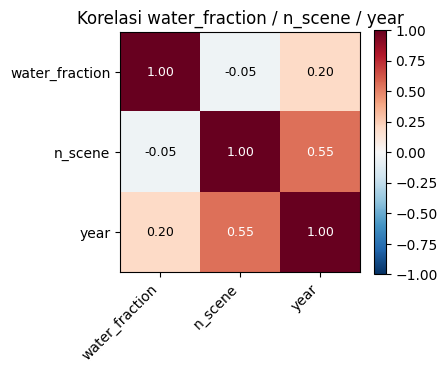

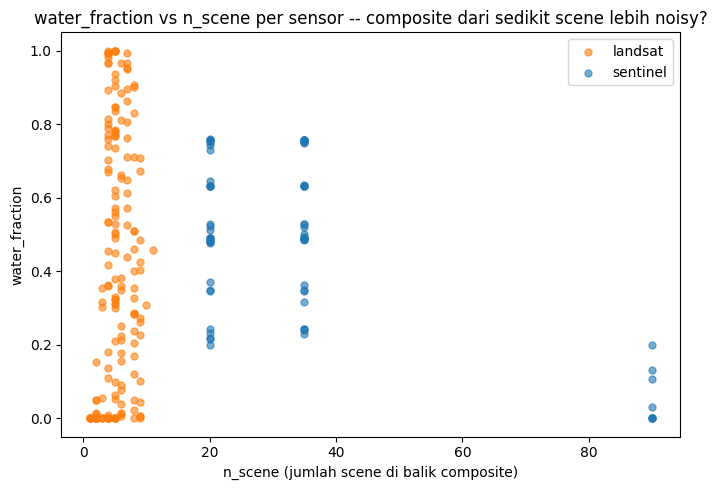

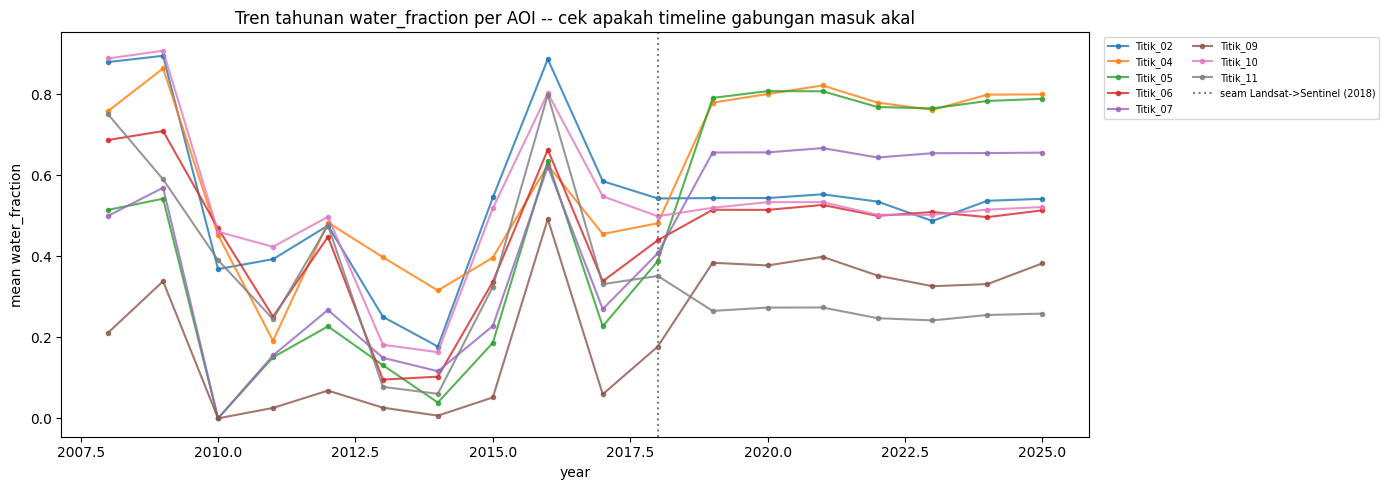

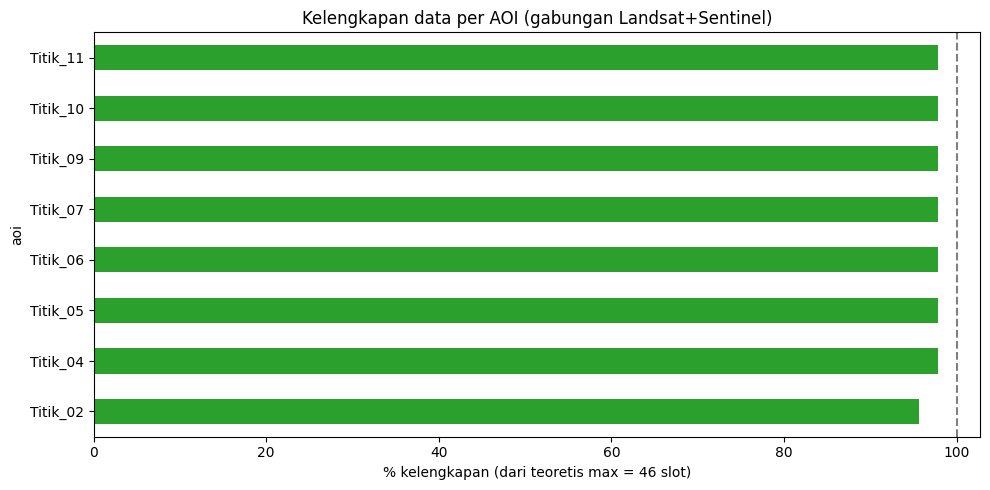

Kelengkapan data (%) per AOI:
aoi
Titik_02    95.7
Titik_04    97.8
Titik_05    97.8
Titik_06    97.8
Titik_07    97.8
Titik_09    97.8
Titik_10    97.8
Titik_11    97.8
dtype: float64


In [11]:
# ============================================================
# CELL 5 — Extended frame_df analytics (more charts, same data as Cell 4)
#
# NOTE: if the charts below still show "_landsat"-suffixed AOI (e.g.
# "Titik_02_landsat" as a separate bar from "Titik_02") or a "Titik_19" AOI,
# that means Cell 3 ran BEFORE the AOI-naming fix -- re-run Cell 3 (then
# Cell 4, then this cell) in a fresh runtime before trusting these charts.
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1. Correlation heatmap (visual version of Cell 4's printed corr()) ----------
corr = frame_df[["water_fraction", "n_scene", "year"]].corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color="white" if abs(val) > 0.5 else "black", fontsize=9)
ax.set_title("Korelasi water_fraction / n_scene / year")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "eda_correlation_heatmap.png"), dpi=120)
plt.show()

# ---------- 2. Scatter: water_fraction vs n_scene, per sensor ----------
fig, ax = plt.subplots(figsize=(7, 5))
for sensor, color in [("landsat", "tab:orange"), ("sentinel", "tab:blue")]:
    sub = frame_df[frame_df.sensor == sensor]
    ax.scatter(sub["n_scene"], sub["water_fraction"], alpha=0.6, label=sensor, color=color, s=25)
ax.set_xlabel("n_scene (jumlah scene di balik composite)")
ax.set_ylabel("water_fraction")
ax.set_title("water_fraction vs n_scene per sensor -- composite dari sedikit scene lebih noisy?")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "eda_scatter_water_vs_nscene.png"), dpi=120)
plt.show()

# ---------- 3. Yearly trend: mean water_fraction per year, 1 line per AOI ----------
yearly = frame_df.groupby(["aoi", "year"])["water_fraction"].mean().reset_index()
fig, ax = plt.subplots(figsize=(14, 5))
for aoi in sorted(yearly["aoi"].unique()):
    sub = yearly[yearly.aoi == aoi].sort_values("year")
    ax.plot(sub["year"], sub["water_fraction"], marker="o", markersize=3, label=aoi, alpha=0.8)
ax.axvline(2018, color="gray", linestyle=":", label="seam Landsat->Sentinel (2018)")
ax.set_xlabel("year"); ax.set_ylabel("mean water_fraction")
ax.set_title("Tren tahunan water_fraction per AOI -- cek apakah timeline gabungan masuk akal")
ax.legend(fontsize=7, ncol=2, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "eda_yearly_trend_per_aoi.png"), dpi=120)
plt.show()

# ---------- 4. Data completeness % per AOI ----------
# Teoretis max per AOI = 11 tahun Landsat x 2 musim (2008-2018) + 8 tahun
# Sentinel x 3 musim (2018-2025). 2018 dihitung di kedua sisi (sedikit
# overcount) -- cukup akurat sbg denominator kasar, bukan angka presisi.
LANDSAT_YEARS_N = 11
SENTINEL_YEARS_N = 8
theoretical_max = LANDSAT_YEARS_N * 2 + SENTINEL_YEARS_N * 3

actual_counts = frame_df.groupby("aoi").size()
completeness_pct = (actual_counts / theoretical_max * 100).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
completeness_pct.plot(kind="barh", ax=ax, color="tab:green")
ax.set_xlabel(f"% kelengkapan (dari teoretis max = {theoretical_max} slot)")
ax.set_title("Kelengkapan data per AOI (gabungan Landsat+Sentinel)")
ax.axvline(100, color="gray", linestyle="--")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "eda_completeness_pct.png"), dpi=120)
plt.show()

print("Kelengkapan data (%) per AOI:")
print(completeness_pct.round(1))


=== A1. Volatilitas year-over-year water_fraction, pre vs post 2018 ===
era       post_2018  pre_2018
aoi                          
Titik_02      0.022     0.217
Titik_04      0.058     0.191
Titik_05      0.081     0.221
Titik_06      0.032     0.213
Titik_07      0.054     0.213
Titik_09      0.060     0.168
Titik_10      0.017     0.201
Titik_11      0.020     0.262


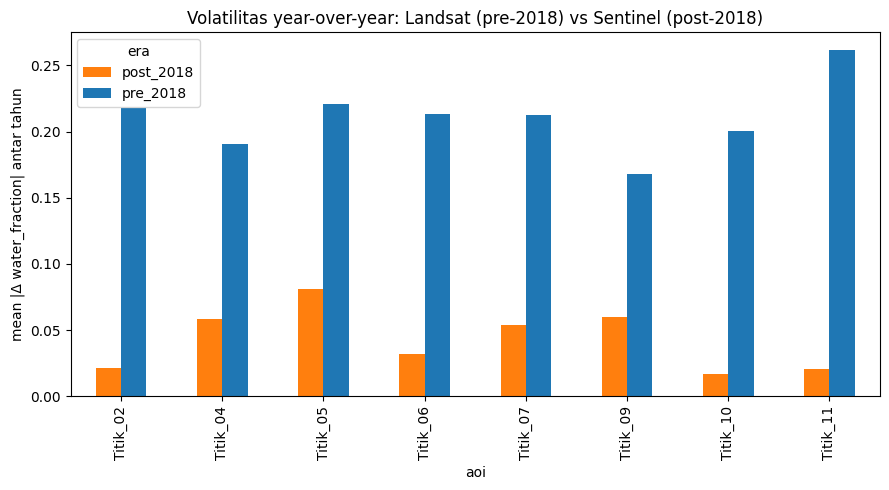


=== A2. Speckle (n_components) per sensor ===
          count      mean       std  min  25%  50%  75%  max
sensor                                                      
landsat   176.0  2.159091  2.019258  0.0  1.0  1.0  3.0  9.0
sentinel  183.0  2.306011  1.219943  0.0  1.0  2.0  3.0  6.0

=== A3. 8 frame di-flag low_reliability (n_components > mean+2std per sensor) ===
          aoi    sensor  year season  n_components
1    Titik_05   landsat  2008     L2             9
23   Titik_07   landsat  2008     L2             9
2    Titik_05   landsat  2009     L1             8
131  Titik_09   landsat  2018     L2             8
111  Titik_09   landsat  2008     L2             7
127  Titik_09   landsat  2016     L2             7
128  Titik_09   landsat  2017     L1             7
334  Titik_02  sentinel  2023     S1             6

=== B. CHIRPS rainfall: 216 bulan ditarik dalam 1 getInfo() call ===
       rainfall_mm
count   216.000000
mean    185.186949
std     149.870571
min       0.000000
25

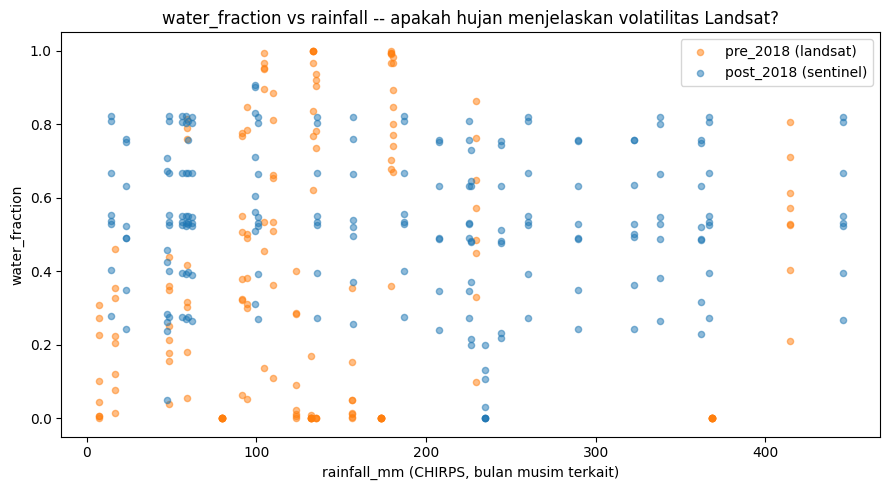


Korelasi rainfall_mm vs water_fraction, per era:
era                      
post_2018  water_fraction   -0.051181
pre_2018   water_fraction    0.071032
Name: rainfall_mm, dtype: float64

✓ frame_df diperkaya (n_components, mean_component_size, low_reliability, rainfall_mm) disimpan ke /content/drive/MyDrive/Data_experiment_shoreline/logs/frame_df_with_reliability.csv
  (belum di-wire ke training loss/model -- follow-up kalau terbukti signifikan)


In [12]:

# ============================================================
# CELL 6 — Reliability/volatility diagnostic + ONE bounded GEE enrichment call
#
# Part A is 100% local (mask arrays + frame_df already in memory) -- zero GEE
# calls. Part B is the ONLY new Earth Engine usage in this whole notebook:
# exactly one batched CHIRPS rainfall pull over the union AOI bbox (not a
# per-AOI/per-year loop -- that pattern is what drove quota to 94% already).
#
# Why: the Cell 5 yearly-trend chart showed pre-2018 (Landsat) water_fraction
# swinging wildly year-to-year (e.g. ~0.9 -> ~0.0 -> ~0.5) while post-2018
# (Sentinel) is much smoother. Real shoreline change doesn't oscillate that
# hard -- likely Landsat 7 SLC-off gaps (2008-2012) + a single Otsu threshold
# fit once on a 2016 reference composite and reused across the whole
# 2008-2018 span (both flagged as risks in all_code2.py). This cell quantifies
# that noise instead of just eyeballing the chart.
# ============================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import measure

# ============================================================
# PART A -- zero-cost, purely local
# ============================================================

# ---------- A1. Year-over-year volatility, pre vs post 2018 ----------
yearly_mean = frame_df.groupby(["aoi", "year"])["water_fraction"].mean().reset_index()
vol_rows = []
for aoi in sorted(yearly_mean["aoi"].unique()):
    sub = yearly_mean[yearly_mean.aoi == aoi].sort_values("year")
    diffs = sub["water_fraction"].diff().abs()
    sub = sub.assign(abs_diff=diffs)
    for era, mask_era in [("pre_2018", sub.year < 2018), ("post_2018", sub.year >= 2018)]:
        era_diffs = sub.loc[mask_era, "abs_diff"].dropna()
        if len(era_diffs):
            vol_rows.append({"aoi": aoi, "era": era, "mean_abs_yoy_diff": era_diffs.mean(),
                              "n_transitions": len(era_diffs)})
volatility_df = pd.DataFrame(vol_rows)
print("=== A1. Volatilitas year-over-year water_fraction, pre vs post 2018 ===")
print(volatility_df.pivot(index="aoi", columns="era", values="mean_abs_yoy_diff").round(3))

fig, ax = plt.subplots(figsize=(9, 5))
piv = volatility_df.pivot(index="aoi", columns="era", values="mean_abs_yoy_diff")
piv.plot(kind="bar", ax=ax, color=["tab:orange", "tab:blue"])
ax.set_ylabel("mean |Δ water_fraction| antar tahun")
ax.set_title("Volatilitas year-over-year: Landsat (pre-2018) vs Sentinel (post-2018)")
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "reliability_yoy_volatility.png"), dpi=120)
plt.show()

# ---------- A2. Mask speckle proxy (connected components) ----------
def _speckle_stats(mask_arr):
    binary = (mask_arr > 0.5)
    labeled, n = measure.label(binary, connectivity=2, return_num=True)
    if n == 0:
        return 0, 0.0
    sizes = np.bincount(labeled.ravel())[1:]  # skip background label 0
    return int(n), float(sizes.mean())


def _add_speckle_rows(masks, sensor):
    rows = []
    for aoi, frames in masks.items():
        for (yr, season), arr in frames.items():
            n_comp, mean_size = _speckle_stats(arr)
            rows.append({"aoi": aoi, "sensor": sensor, "year": yr, "season": season,
                         "n_components": n_comp, "mean_component_size": mean_size})
    return rows


speckle_rows = _add_speckle_rows(masks_landsat, "landsat") + _add_speckle_rows(masks_sentinel, "sentinel")
speckle_df = pd.DataFrame(speckle_rows)
frame_df = frame_df.merge(speckle_df, on=["aoi", "sensor", "year", "season"], how="left")

print("\n=== A2. Speckle (n_components) per sensor ===")
print(frame_df.groupby("sensor")["n_components"].describe())

# ---------- A3. Flag low-reliability frames (outlier n_components within sensor) ----------
stats = frame_df.groupby("sensor")["n_components"].transform(lambda s: (s - s.mean()) / (s.std() + 1e-9))
frame_df["low_reliability"] = stats > 2.0

low_rel = frame_df[frame_df["low_reliability"]][["aoi", "sensor", "year", "season", "n_components"]]
print(f"\n=== A3. {len(low_rel)} frame di-flag low_reliability (n_components > mean+2std per sensor) ===")
print(low_rel.sort_values(["sensor", "n_components"], ascending=[True, False]))

# ============================================================
# PART B -- exactly ONE bounded GEE call (CHIRPS rainfall, union bbox)
# ============================================================
import ee

try:
    ee.Initialize(project=GEE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)

# Union bbox over all AOI centers (same pattern as all_code2.py's get_union_bbox,
# reused here to keep this to ONE geometry / ONE batched call, not per-AOI loops).
_lons = [v["lon"] for v in manifest_sentinel["aoi"].values()] + [v["lon"] for v in manifest_landsat["aoi"].values()]
_lats = [v["lat"] for v in manifest_sentinel["aoi"].values()] + [v["lat"] for v in manifest_landsat["aoi"].values()]
pad_deg = 0.02
UNION_BBOX = ee.Geometry.Rectangle([min(_lons) - pad_deg, min(_lats) - pad_deg,
                                     max(_lons) + pad_deg, max(_lats) + pad_deg])

chirps = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterBounds(UNION_BBOX)
months = pd.date_range("2008-01-01", "2025-12-31", freq="MS")
month_starts = [ee.Date(m.strftime("%Y-%m-%d")) for m in months]


def _monthly_rainfall(d):
    d = ee.Date(d)
    monthly = chirps.filterDate(d, d.advance(1, "month")).sum()
    mean_mm = monthly.reduceRegion(reducer=ee.Reducer.mean(), geometry=UNION_BBOX,
                                    scale=5000, maxPixels=1e9).get("precipitation")
    return ee.Feature(None, {"date": d.format("YYYY-MM"), "rainfall_mm": mean_mm})


rainfall_fc = ee.FeatureCollection([_monthly_rainfall(d) for d in month_starts])
rainfall_list = rainfall_fc.getInfo()["features"]  # <-- the ONE .getInfo() call for this whole cell
rainfall_monthly = pd.DataFrame([f["properties"] for f in rainfall_list])
rainfall_monthly["year"] = rainfall_monthly["date"].str[:4].astype(int)
rainfall_monthly["month"] = rainfall_monthly["date"].str[5:7].astype(int)
print(f"\n=== B. CHIRPS rainfall: {len(rainfall_monthly)} bulan ditarik dalam 1 getInfo() call ===")
print(rainfall_monthly[["date", "rainfall_mm"]].describe())

# Join onto frame_df by (year, season) -> nearest covered month for that season's midpoint
_SEASON_MONTH = {"L1": 4, "L2": 10, "S1": 3, "S2": 7, "S3": 11}
frame_df["_season_month"] = frame_df["season"].map(_SEASON_MONTH)
frame_df = frame_df.merge(
    rainfall_monthly.rename(columns={"month": "_season_month"})[["year", "_season_month", "rainfall_mm"]],
    on=["year", "_season_month"], how="left"
).drop(columns="_season_month")

fig, ax = plt.subplots(figsize=(9, 5))
for era, mask_era, color in [("pre_2018 (landsat)", frame_df.year < 2018, "tab:orange"),
                              ("post_2018 (sentinel)", frame_df.year >= 2018, "tab:blue")]:
    sub = frame_df[mask_era]
    ax.scatter(sub["rainfall_mm"], sub["water_fraction"], alpha=0.5, label=era, color=color, s=20)
ax.set_xlabel("rainfall_mm (CHIRPS, bulan musim terkait)")
ax.set_ylabel("water_fraction")
ax.set_title("water_fraction vs rainfall -- apakah hujan menjelaskan volatilitas Landsat?")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "reliability_rainfall_vs_water.png"), dpi=120)
plt.show()

print("\nKorelasi rainfall_mm vs water_fraction, per era:")
print(frame_df.assign(era=np.where(frame_df.year < 2018, "pre_2018", "post_2018"))
      .groupby("era")[["water_fraction", "rainfall_mm"]].corr(numeric_only=True).iloc[0::2, -1])

# ============================================================
# SAVE -- enriched frame_df, NOT wired into training this pass
# ============================================================
out_csv = os.path.join(LOG_DIR, "frame_df_with_reliability.csv")
frame_df.to_csv(out_csv, index=False)
print(f"\n✓ frame_df diperkaya (n_components, mean_component_size, low_reliability, rainfall_mm) "
      f"disimpan ke {out_csv}")
print("  (belum di-wire ke training loss/model -- follow-up kalau terbukti signifikan)")

[Titik_02] static features OK -- shape (3, 256, 256)
[Titik_04] static features OK -- shape (3, 256, 256)
[Titik_05] static features OK -- shape (3, 256, 256)
[Titik_06] static features OK -- shape (3, 256, 256)
[Titik_07] static features OK -- shape (3, 256, 256)
[Titik_09] static features OK -- shape (3, 256, 256)
[Titik_10] static features OK -- shape (3, 256, 256)
[Titik_11] static features OK -- shape (3, 256, 256)

8/8 AOI berhasil, 0 gagal: []
✓ Static features (elevation, slope, mangrove) disimpan ke /content/drive/MyDrive/Data_experiment_shoreline/logs/static_features.npz


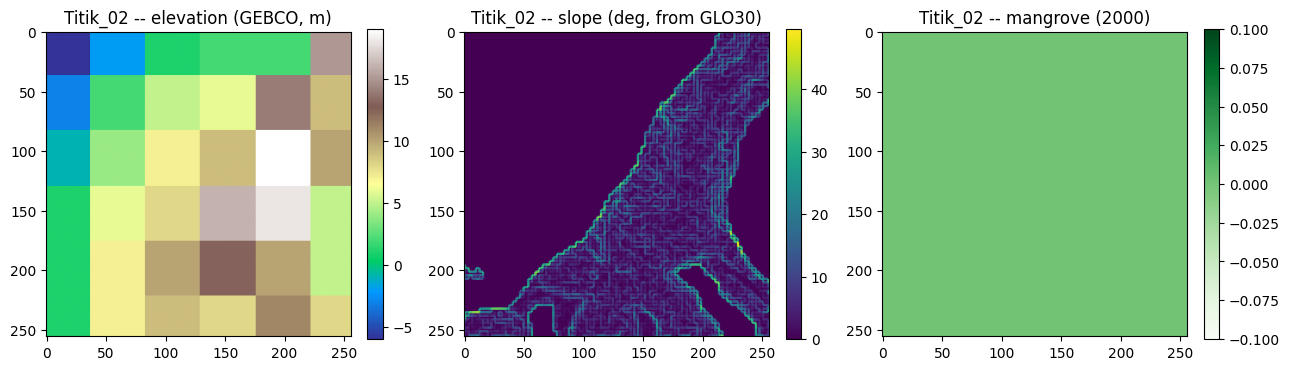

In [13]:

# ============================================================
# CELL 6 Part D — Static per-pixel enrichment: elevation, bathymetry, slope, mangrove
#   ONE-TIME fetch per AOI (not per year/season) -- cheapest way to add genuine
#   per-pixel richness given GEE quota is nearly exhausted.
#
# Datasets (researched, confirmed static / no time dimension):
#   - GEBCO bathymetry/elevation grid: projects/sat-io/open-datasets/gebco/gebco_grid
#   - Copernicus GLO-30 DEM (land elevation): COPERNICUS/DEM/GLO30
#   - Slope: computed LOCALLY from the downloaded GLO30 array (np.gradient) --
#     zero extra GEE call, instead of a 4th ee.Terrain.slope() download.
#   - Mangrove extent (year-2000 epoch, already used elsewhere in this repo's
#     modelling_pt4.ipynb): LANDSAT/MANGROVE_FORESTS
#
# Ocean currents and sediment/turbidity were researched and excluded: currents
# aren't a GEE-native dataset (would need an external API like CMEMS/NOAA
# ERDDAP), and sediment/turbidity would require re-fetching raw spectral bands
# per scene -- same cost class as the original (already-spent) data collection.
#
# Cost: 8 AOI x 2 raster downloads (GEBCO + GLO30) + 1 mangrove crop each = 24
# total ONE-TIME pixel-array pulls. Nothing here is a time series.
#
# Requires _fit_patch (defined in the Cell 4 dimension-validation cell) to
# already be in scope -- reused here rather than redefined.
# ============================================================
import os
import io
import time
import requests
import numpy as np
import ee

try:
    ee.Initialize(project=GEE_PROJECT)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=GEE_PROJECT)


# Same crop-region pattern as all_code2.py's export_landsat_all
def _patch_region(lon, lat, patch_size=PATCH_SIZE, scale_m=SCALE_M):
    return ee.Geometry.Point([lon, lat]).buffer(patch_size * scale_m / 2).bounds()


def _download_patch(image, band, region, scale=SCALE_M, patch_size=PATCH_SIZE, max_retry=3):
    last_err = None
    for attempt in range(max_retry):
        try:
            url = image.select(band).getDownloadURL({"region": region, "scale": scale, "format": "NPY"})
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            arr = np.load(io.BytesIO(r.content))[band].astype(np.float32)
            return _fit_patch(arr, patch_size)  # reused from Cell 4
        except Exception as e:
            last_err = e
            if attempt < max_retry - 1:
                time.sleep(5 * (attempt + 1))
    raise RuntimeError(f"Gagal download band {band}: {last_err}")


gebco = ee.ImageCollection("projects/sat-io/open-datasets/gebco/gebco_grid").mosaic().rename("elevation_gebco")
glo30 = ee.ImageCollection("COPERNICUS/DEM/GLO30").mosaic().select("DEM").rename("elevation_glo30")
mangrove_coll = ee.ImageCollection("LANDSAT/MANGROVE_FORESTS")

AOI_LONLAT = {}
for nama, info in {**manifest_sentinel["aoi"], **manifest_landsat["aoi"]}.items():
    if nama not in AOI_LONLAT:
        AOI_LONLAT[nama] = (info["lon"], info["lat"])

static_features = {}
failed_static = []
for nama, (lon, lat) in AOI_LONLAT.items():
    region = _patch_region(lon, lat)
    try:
        elevation = _download_patch(gebco, "elevation_gebco", region)
        elevation_glo30 = _download_patch(glo30, "elevation_glo30", region)

        # Slope computed LOCALLY from the elevation_glo30 array -- zero extra GEE call
        gy, gx = np.gradient(elevation_glo30, SCALE_M)
        slope = np.degrees(np.arctan(np.hypot(gx, gy))).astype(np.float32)

        aoi_geom = ee.Geometry.Point([lon, lat]).buffer(PATCH_SIZE * SCALE_M / 2)
        mangrove_img = ee.Image(ee.Algorithms.If(
            mangrove_coll.filterBounds(aoi_geom).size().gt(0),
            mangrove_coll.filterBounds(aoi_geom).mosaic().clip(aoi_geom).rename("mangrove"),
            ee.Image.constant(0).clip(aoi_geom).rename("mangrove"),
        ))
        mangrove = _download_patch(mangrove_img, "mangrove", region)

        static_features[nama] = np.stack([elevation, slope, mangrove], axis=0).astype(np.float32)
        print(f"[{nama}] static features OK -- shape {static_features[nama].shape}")
    except Exception as e:
        failed_static.append((nama, str(e)))
        print(f"[{nama}] GAGAL: {e}")

print(f"\n{len(static_features)}/{len(AOI_LONLAT)} AOI berhasil, {len(failed_static)} gagal: {failed_static}")

out_path = os.path.join(LOG_DIR, "static_features.npz")
np.savez_compressed(out_path, **static_features)
print(f"✓ Static features (elevation, slope, mangrove) disimpan ke {out_path}")

# ---------- quick sanity plot: 1 AOI, 3 layers ----------
import matplotlib.pyplot as plt
_sample_aoi = next(iter(static_features))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ["elevation (GEBCO, m)", "slope (deg, from GLO30)", "mangrove (2000)"]
cmaps = ["terrain", "viridis", "Greens"]
for i, ax in enumerate(axes):
    im = ax.imshow(static_features[_sample_aoi][i], cmap=cmaps[i])
    ax.set_title(f"{_sample_aoi} -- {titles[i]}")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "static_features_sample.png"), dpi=120)
plt.show()

[Titik_02] WorldCover OK -- 61 mangrove pixel(s) di patch ini (class 95)
[Titik_04] WorldCover OK -- 128 mangrove pixel(s) di patch ini (class 95)
[Titik_05] WorldCover OK -- 1532 mangrove pixel(s) di patch ini (class 95)
[Titik_06] WorldCover OK -- 607 mangrove pixel(s) di patch ini (class 95)
[Titik_07] WorldCover OK -- 0 mangrove pixel(s) di patch ini (class 95)
[Titik_09] WorldCover OK -- 4185 mangrove pixel(s) di patch ini (class 95)
[Titik_10] WorldCover OK -- 0 mangrove pixel(s) di patch ini (class 95)
[Titik_11] WorldCover OK -- 10577 mangrove pixel(s) di patch ini (class 95)

8/8 AOI dapat WorldCover, 0 gagal: []
✓ static_features.npz diupdate -- sekarang 5 channel (elevation, slope, mangrove_2000, landcover_class, is_mangrove_worldcover)


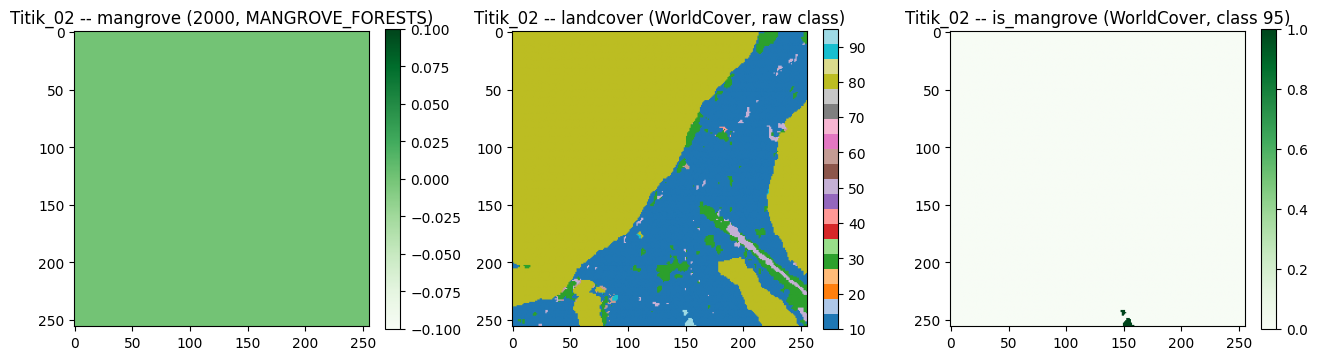

In [14]:

# ============================================================
# CELL 6 Part E — ESA WorldCover land cover (fixes the flat MANGROVE_FORESTS layer)
#
# LANDSAT/MANGROVE_FORESTS (year 2000, 30m) came back ~blank for small AOI
# patches -- too coarse / too old for this scale. ESA WorldCover v200 (2021
# epoch, confirmed via web search) is 10m native (matches SCALE_M exactly) and
# has a dedicated Mangroves class (code 95), plus full land-cover context.
# Still static/single-snapshot -- one more one-time fetch per AOI, not a time
# series.
#
# Requires Part D to have already run in this session (_download_patch,
# _patch_region, PATCH_SIZE, SCALE_M, static_features dict all reused).
# ============================================================
import os
import numpy as np

worldcover = ee.ImageCollection("ESA/WorldCover/v200").first().select("Map").rename("landcover")
MANGROVE_CLASS_CODE = 95

failed_worldcover = []
for nama, (lon, lat) in AOI_LONLAT.items():
    if nama not in static_features:
        continue  # skip AOI that already failed in Part D
    region = _patch_region(lon, lat)
    try:
        landcover = _download_patch(worldcover, "landcover", region)
        is_mangrove_wc = (landcover == MANGROVE_CLASS_CODE).astype(np.float32)

        static_features[nama] = np.concatenate([
            static_features[nama],                      # (3, H, W): elevation, slope, mangrove(2000)
            landcover[np.newaxis].astype(np.float32),    # (1, H, W): raw WorldCover class code
            is_mangrove_wc[np.newaxis],                  # (1, H, W): binary mangrove-from-WorldCover
        ], axis=0)
        n_mangrove_px = int(is_mangrove_wc.sum())
        print(f"[{nama}] WorldCover OK -- {n_mangrove_px} mangrove pixel(s) di patch ini (class {MANGROVE_CLASS_CODE})")
    except Exception as e:
        failed_worldcover.append((nama, str(e)))
        print(f"[{nama}] GAGAL WorldCover: {e}")

print(f"\n{len(static_features) - len(failed_worldcover)}/{len(static_features)} AOI dapat WorldCover, "
      f"{len(failed_worldcover)} gagal: {failed_worldcover}")

out_path = os.path.join(LOG_DIR, "static_features.npz")
np.savez_compressed(out_path, **static_features)
print(f"✓ static_features.npz diupdate -- sekarang {next(iter(static_features.values())).shape[0]} channel "
      f"(elevation, slope, mangrove_2000, landcover_class, is_mangrove_worldcover)")

# ---------- sanity plot: compare OLD mangrove(2000) vs NEW WorldCover mangrove ----------
import matplotlib.pyplot as plt
_sample_aoi = next(iter(static_features))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
titles = ["mangrove (2000, MANGROVE_FORESTS)", "landcover (WorldCover, raw class)", "is_mangrove (WorldCover, class 95)"]
cmaps = ["Greens", "tab20", "Greens"]
for i, (ax, ch_idx) in enumerate(zip(axes, [2, 3, 4])):
    im = ax.imshow(static_features[_sample_aoi][ch_idx], cmap=cmaps[i])
    ax.set_title(f"{_sample_aoi} -- {titles[i]}")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "static_features_worldcover_sample.png"), dpi=120)
plt.show()

[Titik_02] SDB index OK (165 scene) -- range [0.000, 1.433]
[Titik_04] SDB index OK (165 scene) -- range [0.000, 1.509]
[Titik_05] SDB index OK (166 scene) -- range [0.000, 1.722]
[Titik_06] SDB index OK (165 scene) -- range [0.000, 1.459]
[Titik_07] SDB index OK (166 scene) -- range [0.000, 1.431]
[Titik_09] SDB index OK (166 scene) -- range [0.000, 1.722]
[Titik_10] SDB index OK (166 scene) -- range [0.000, 1.439]
[Titik_11] SDB index OK (166 scene) -- range [0.000, 1.433]

8/8 AOI dapat SDB index, 0 gagal: []
✓ static_features.npz diupdate -- sekarang 6 channel (+ sdb_index, relatif/belum terkalibrasi ke meter)


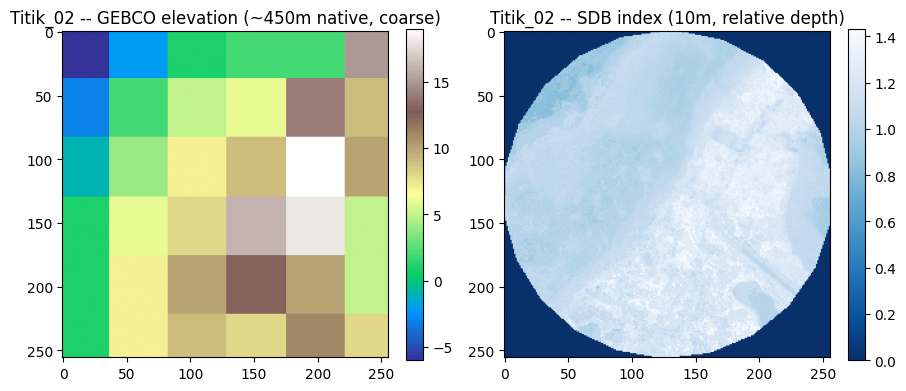

In [15]:
# ============================================================
# CELL 6 Part F — Satellite-derived bathymetry (SDB) index, Stumpf (2003) ratio
#
# No verified second ready-made GEE bathymetry dataset exists finer than GEBCO
# (Allen Coral Atlas's GEE asset has no depth band; GLOBathy/DeltaDTM/CoNED all
# ruled out -- see notes). This computes a RELATIVE depth index locally from one
# cloud-free Sentinel-2 composite per AOI -- NOT calibrated to meters, but 10m
# resolution vs GEBCO's ~450m, so it resolves within-patch depth variation.
#
# Requires Part D to have already run (_patch_region, static_features, AOI_LONLAT,
# PATCH_SIZE, SCALE_M all reused).
# ============================================================
import os
import io
import time
import requests
import numpy as np
import ee

CLOUD_FILTER = 30  # % -- same threshold used elsewhere in this repo's S2 pipeline


def _sdb_index(lon, lat, region, year_window=("2022-01-01", "2025-12-31")):
    """One cloud-free-ish S2 composite (most recent available), NOT a time series --
    fetched once per AOI, same discipline as Parts D/E."""
    aoi_geom = ee.Geometry.Point([lon, lat]).buffer(PATCH_SIZE * SCALE_M / 2)
    col = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
           .filterBounds(aoi_geom)
           .filterDate(*year_window)
           .filter(ee.Filter.lte("CLOUDY_PIXEL_PERCENTAGE", CLOUD_FILTER))
           .sort("CLOUDY_PIXEL_PERCENTAGE"))
    n = col.size().getInfo()
    if n == 0:
        raise RuntimeError("Tidak ada scene S2 cukup jernih di window ini")
    img = col.median().clip(aoi_geom)
    # Stumpf ratio: ln(Blue)/ln(Green) -- SR values are int16 scaled by 1e4 in S2_SR
    blue = img.select("B2").multiply(0.0001).max(1e-6)
    green = img.select("B3").multiply(0.0001).max(1e-6)
    sdb = blue.log().divide(green.log()).rename("sdb_index")
    return sdb, n


def _download_sdb(sdb_img, region, patch_size=PATCH_SIZE, scale=SCALE_M, max_retry=3):
    last_err = None
    for attempt in range(max_retry):
        try:
            url = sdb_img.getDownloadURL({"region": region, "scale": scale, "format": "NPY"})
            r = requests.get(url, timeout=60)
            r.raise_for_status()
            arr = np.load(io.BytesIO(r.content))["sdb_index"].astype(np.float32)
            return _fit_patch(arr, patch_size)
        except Exception as e:
            last_err = e
            if attempt < max_retry - 1:
                time.sleep(5 * (attempt + 1))
    raise RuntimeError(f"Gagal download SDB: {last_err}")


failed_sdb = []
for nama, (lon, lat) in AOI_LONLAT.items():
    if nama not in static_features:
        continue  # skip AOI that already failed in Part D
    region = _patch_region(lon, lat)
    try:
        sdb_img, n_scene = _sdb_index(lon, lat, region)
        sdb_arr = _download_sdb(sdb_img, region)

        static_features[nama] = np.concatenate([
            static_features[nama],                  # (5, H, W): from Parts D+E
            sdb_arr[np.newaxis],                    # (1, H, W): SDB relative depth index
        ], axis=0)
        print(f"[{nama}] SDB index OK ({n_scene} scene) -- range [{sdb_arr.min():.3f}, {sdb_arr.max():.3f}]")
    except Exception as e:
        failed_sdb.append((nama, str(e)))
        print(f"[{nama}] GAGAL SDB: {e}")

print(f"\n{len(static_features) - len(failed_sdb)}/{len(static_features)} AOI dapat SDB index, "
      f"{len(failed_sdb)} gagal: {failed_sdb}")

out_path = os.path.join(LOG_DIR, "static_features.npz")
np.savez_compressed(out_path, **static_features)
print(f"✓ static_features.npz diupdate -- sekarang {next(iter(static_features.values())).shape[0]} channel "
      f"(+ sdb_index, relatif/belum terkalibrasi ke meter)")

# ---------- sanity plot: GEBCO (coarse, absolute-ish) vs SDB index (fine, relative) ----------
import matplotlib.pyplot as plt
_sample_aoi = next(iter(static_features))
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
im0 = axes[0].imshow(static_features[_sample_aoi][0], cmap="terrain")
axes[0].set_title(f"{_sample_aoi} -- GEBCO elevation (~450m native, coarse)")
fig.colorbar(im0, ax=axes[0], fraction=0.046)
im1 = axes[1].imshow(static_features[_sample_aoi][-1], cmap="Blues_r")
axes[1].set_title(f"{_sample_aoi} -- SDB index (10m, relative depth)")
fig.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, "static_features_sdb_sample.png"), dpi=120)
plt.show()

In [16]:
# ============================================================
# CELL 7 — Combine Landsat (L1/L2, 2008-2018) + Sentinel-2 (S1/S2/S3, 2018-2025)
#   into ONE chronological per-AOI frame sequence, AND load the static per-pixel
#   enrichment features (elevation, slope, mangrove, landcover, SDB index) built
#   in Cell 6 Parts D/E/F.
#
# Landsat & Sentinel don't share a season grid (2/year vs 3/year), so instead
# of trying to force them onto the same season codes, every frame is converted
# to a continuous time value t = year + month_midpoint/12. This is the join key
# for the rest of the notebook (build_tensor in Cell 8, plotting in Cell 10).
#
# 2018 overlap: both sensors have frames that year. Sentinel (native 10m, no
# resampling) wins; the corresponding Landsat frame is dropped and logged below
# so the decision is auditable, not silent.
#
# static_features (from Cell 6 Parts D/E/F) is loaded here too -- not because it
# needs merging (it's static, no time dimension, same array reused across every
# timestep for a given AOI), but because this is the natural checkpoint before
# tensor-building (Cell 8) to confirm every AOI in combined_masks actually has a
# matching static-feature stack, so a missing AOI doesn't surface later as a
# confusing KeyError deep inside tensor construction.
# ============================================================
import os
import numpy as np

SEASON_MONTH_MIDPOINT = {
    "L1": 4, "L2": 10,          # Landsat: 2 seasons/year (all_code2.py LANDSAT_SEASONS)
    "S1": 3, "S2": 7, "S3": 11,  # Sentinel: 3 seasons/year (all_code2.py SEASON_MONTHS)
}


def season_to_t(year, season):
    return year + SEASON_MONTH_MIDPOINT[season] / 12.0


all_aoi = sorted(set(masks_landsat.keys()) | set(masks_sentinel.keys()))
combined_masks = {}     # aoi -> {t: mask_array}, sorted by t
combined_source = {}    # aoi -> {t: (sensor, year, season)}
combine_log = []

for aoi in all_aoi:
    frames, source = {}, {}
    for (yr, s), arr in masks_landsat.get(aoi, {}).items():
        t = season_to_t(yr, s)
        frames[t] = arr
        source[t] = ("landsat", yr, s)
    for (yr, s), arr in masks_sentinel.get(aoi, {}).items():
        t = season_to_t(yr, s)
        if t in frames and source[t][0] == "landsat":
            dropped = source[t]
            combine_log.append(
                f"[{aoi}] t={t:.3f}: dropped Landsat {dropped[1]}_{dropped[2]} "
                f"in favor of Sentinel {yr}_{s} (overlap year)"
            )
        frames[t] = arr
        source[t] = ("sentinel", yr, s)

    ts_sorted = sorted(frames.keys())
    combined_masks[aoi] = {t: frames[t] for t in ts_sorted}
    combined_source[aoi] = {t: source[t] for t in ts_sorted}

print(f"{len(combine_log)} frame(s) di-drop karena overlap 2018 (Landsat kalah dari Sentinel):")
for line in combine_log:
    print(" ", line)

print("\nRingkasan per-AOI setelah merge:")
for aoi in all_aoi:
    ts = sorted(combined_masks[aoi].keys())
    n_landsat = sum(1 for t in ts if combined_source[aoi][t][0] == "landsat")
    n_sentinel = sum(1 for t in ts if combined_source[aoi][t][0] == "sentinel")
    span = f"{ts[0]:.2f}-{ts[-1]:.2f}" if ts else "n/a"
    print(f"  {aoi:12s} | {len(ts):3d} frame total ({n_landsat} landsat + {n_sentinel} sentinel) | span {span}")

# ============================================================
# NEW -- load static per-pixel features (Cell 6 Parts D/E/F), cross-check coverage
# ============================================================
STATIC_FEATURE_NAMES = ["elevation_gebco", "slope", "mangrove_2000", "landcover_class",
                         "is_mangrove_worldcover", "sdb_index"]

static_path = os.path.join(LOG_DIR, "static_features.npz")
if os.path.exists(static_path):
    _z = np.load(static_path)
    static_features = {aoi: _z[aoi] for aoi in _z.files}
    n_channels = next(iter(static_features.values())).shape[0] if static_features else 0
    print(f"\nStatic features dimuat: {len(static_features)} AOI, {n_channels} channel "
          f"({', '.join(STATIC_FEATURE_NAMES[:n_channels])})")

    missing_static = [aoi for aoi in all_aoi if aoi not in static_features]
    if missing_static:
        print(f"⚠️  AOI TANPA static features (Cell 6 Part D/E/F gagal/belum jalan buat ini): {missing_static}")
        print("    -- build_tensor di Cell 8 akan skip AOI ini kalau mau pakai static channels.")
    else:
        print("✓ Semua AOI di combined_masks punya static features yang cocok.")
else:
    static_features = {}
    print(f"\n⚠️  {static_path} tidak ditemukan -- Cell 6 Part D/E/F belum dijalankan. "
          f"static_features kosong; Cell 8 akan jalan cuma pakai water mask (in_ch=1) "
          f"kecuali cell ini dijalankan ulang setelah Part D/E/F selesai.")

0 frame(s) di-drop karena overlap 2018 (Landsat kalah dari Sentinel):

Ringkasan per-AOI setelah merge:
  Titik_02     |  44 frame total (22 landsat + 22 sentinel) | span 2008.33-2025.92
  Titik_04     |  45 frame total (22 landsat + 23 sentinel) | span 2008.33-2025.92
  Titik_05     |  45 frame total (22 landsat + 23 sentinel) | span 2008.33-2025.92
  Titik_06     |  45 frame total (22 landsat + 23 sentinel) | span 2008.33-2025.92
  Titik_07     |  45 frame total (22 landsat + 23 sentinel) | span 2008.33-2025.92
  Titik_09     |  45 frame total (22 landsat + 23 sentinel) | span 2008.33-2025.92
  Titik_10     |  45 frame total (22 landsat + 23 sentinel) | span 2008.33-2025.92
  Titik_11     |  45 frame total (22 landsat + 23 sentinel) | span 2008.33-2025.92

Static features dimuat: 8 AOI, 6 channel (elevation_gebco, slope, mangrove_2000, landcover_class, is_mangrove_worldcover, sdb_index)
✓ Semua AOI di combined_masks punya static features yang cocok.


In [17]:
# ============================================================
# CELL 8 — Transform: sliding windows -> multi-step tensors (+ static features),
#          temporal split, SAVE to Drive (final_data/) so a dropped session
#          doesn't force you to redo Cells 1-7.
#
# Landsat cadence (~1/2 yr) and Sentinel cadence (~1/3 yr) aren't evenly spaced
# once merged, and both have real data gaps. So instead of all_code2.py's exact
# seq_index() contiguity check (which assumes a fixed 3-per-year grid), windows
# are accepted based on a MAX_GAP_YEARS tolerance on consecutive t's.
#
# Each sample now carries ROLLOUT_STEPS future targets (not just 1), needed for
# the multi-step rollout loss in Cell 9.
#
# NEW: each AOI's static_features stack (Cell 6 Parts D/E/F, loaded in Cell 7)
# is broadcast across all LOOKBACK timesteps and concatenated onto the water
# mask channel -- AOI whose static stack has a different channel count than the
# majority (partial Part D/E/F failures) are SKIPPED with a warning, not
# silently zero-padded, since that would quietly feed the model fake data.
# ============================================================
import os
import json
import collections
import numpy as np
import torch

ROLLOUT_STEPS = 3       # how many future steps the training loss looks at per sample
MAX_GAP_YEARS = 0.6     # reject a window if any consecutive frame gap exceeds this
TRAIN_UNTIL = 2023      # samples whose FIRST target year is <= this go to train

# ---------- determine the "canonical" static-feature channel count ----------
_channel_counts = collections.Counter(v.shape[0] for v in static_features.values())
N_STATIC_CH = _channel_counts.most_common(1)[0][0] if _channel_counts else 0
_bad_static_aoi = [aoi for aoi, v in static_features.items() if v.shape[0] != N_STATIC_CH]
if _bad_static_aoi:
    print(f"⚠️  AOI dgn jumlah channel static BEDA dari mayoritas ({N_STATIC_CH}), di-skip dari "
          f"static enrichment (bukan di-zero-pad, biar gak feed data palsu): {_bad_static_aoi}")
print(f"Static feature channels dipakai: {N_STATIC_CH} (dari {len(static_features) - len(_bad_static_aoi)} AOI)")


def build_multistep_tensor(combined_masks, static_features, lookback=LOOKBACK,
                            rollout_steps=ROLLOUT_STEPS, max_gap=MAX_GAP_YEARS,
                            n_static_ch=N_STATIC_CH):
    X_list, y_list, meta = [], [], []
    n_needed = lookback + rollout_steps
    n_skipped_no_static = 0
    for aoi, frames in combined_masks.items():
        static_stack = static_features.get(aoi)
        use_static = (n_static_ch > 0 and static_stack is not None
                      and static_stack.shape[0] == n_static_ch)
        if n_static_ch > 0 and not use_static:
            n_skipped_no_static += 1
            continue  # AOI has no (or mismatched) static features -- skip, don't fake it

        ts = sorted(frames.keys())
        for i in range(len(ts) - n_needed + 1):
            window_ts = ts[i:i + n_needed]
            gaps = [window_ts[j + 1] - window_ts[j] for j in range(len(window_ts) - 1)]
            if max(gaps) > max_gap:
                continue
            in_ts = window_ts[:lookback]
            target_ts = window_ts[lookback:lookback + rollout_steps]

            mask_stack = np.stack([frames[t][np.newaxis] for t in in_ts])  # (lookback, 1, H, W)
            if use_static:
                static_bcast = np.broadcast_to(
                    static_stack[np.newaxis], (lookback, *static_stack.shape)
                )  # (lookback, n_static_ch, H, W)
                x_sample = np.concatenate([mask_stack, static_bcast], axis=1)  # (lookback, 1+C, H, W)
            else:
                x_sample = mask_stack  # in_ch=1 fallback if no static features at all

            X_list.append(x_sample)
            y_list.append(np.stack([frames[t][np.newaxis] for t in target_ts]))
            meta.append({
                "aoi": aoi, "input_t": list(in_ts), "target_t": list(target_ts),
                "target_year": int(target_ts[0]),
            })

    if n_skipped_no_static:
        print(f"{n_skipped_no_static} AOI di-skip total (tanpa static features yang cocok).")

    X = np.stack(X_list)  # (N, lookback, 1[+n_static_ch], H, W)
    y = np.stack(y_list)  # (N, rollout_steps, 1, H, W)
    print(f"Tensor: X{X.shape} y{y.shape} | {len(meta)} sample dari "
          f"{len(set(m['aoi'] for m in meta))} AOI (lookback={lookback}, "
          f"rollout_steps={rollout_steps}, max_gap={max_gap} th, static_ch={n_static_ch})")
    return X, y, meta


X, y, meta = build_multistep_tensor(combined_masks, static_features)
IN_CH = 1 + N_STATIC_CH if N_STATIC_CH > 0 else 1
print(f"IN_CH buat Cell 9's ConvLSTMUNet: {IN_CH}")

tr = [i for i, m in enumerate(meta) if m["target_year"] <= TRAIN_UNTIL]
te = [i for i, m in enumerate(meta) if m["target_year"] > TRAIN_UNTIL]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

X_train = torch.from_numpy(X[tr]).float().to(device)
y_train = torch.from_numpy(y[tr]).float().to(device)
X_test  = torch.from_numpy(X[te]).float().to(device)
y_test  = torch.from_numpy(y[te]).float().to(device)
meta_train = [meta[i] for i in tr]
meta_test  = [meta[i] for i in te]
print(f"Train: {len(tr)} sample (target ≤ {TRAIN_UNTIL}) | Test: {len(te)} sample (target > {TRAIN_UNTIL})")

# ============================================================
# NEW -- save finished tensors to a fresh Drive subfolder, so a dropped Colab
# session doesn't force re-running Cells 1-7 (incl. GEE calls) from scratch.
# ============================================================
FINAL_DATA_DIR = "/content/drive/MyDrive/Data_experiment_shoreline/final_data"
os.makedirs(FINAL_DATA_DIR, exist_ok=True)

np.savez_compressed(os.path.join(FINAL_DATA_DIR, "tensors.npz"),
                     X=X, y=y, tr=np.array(tr), te=np.array(te))
with open(os.path.join(FINAL_DATA_DIR, "meta.json"), "w") as f:
    json.dump(meta, f)
with open(os.path.join(FINAL_DATA_DIR, "params.json"), "w") as f:
    json.dump({
        "LOOKBACK": LOOKBACK, "ROLLOUT_STEPS": ROLLOUT_STEPS, "MAX_GAP_YEARS": MAX_GAP_YEARS,
        "TRAIN_UNTIL": TRAIN_UNTIL, "IN_CH": IN_CH, "N_STATIC_CH": N_STATIC_CH,
        "PATCH_SIZE": PATCH_SIZE, "SCALE_M": SCALE_M,
        "static_feature_names": STATIC_FEATURE_NAMES[:N_STATIC_CH] if N_STATIC_CH else [],
        "n_train": len(tr), "n_test": len(te),
    }, f, indent=2)

print(f"\n✓ Tensors + meta + params disimpan ke {FINAL_DATA_DIR}")
print("  Kalau session drop lagi: load ulang dari sini (np.load + json.load) alih-alih")
print("  rerun Cell 1-7 dari awal (dan gak nyentuh GEE lagi).")

Static feature channels dipakai: 6 (dari 8 AOI)
Tensor: X(314, 3, 7, 256, 256) y(314, 3, 1, 256, 256) | 314 sample dari 8 AOI (lookback=3, rollout_steps=3, max_gap=0.6 th, static_ch=6)
IN_CH buat Cell 9's ConvLSTMUNet: 7
Device: cuda
Train: 282 sample (target ≤ 2023) | Test: 32 sample (target > 2023)

✓ Tensors + meta + params disimpan ke /content/drive/MyDrive/Data_experiment_shoreline/final_data
  Kalau session drop lagi: load ulang dari sini (np.load + json.load) alih-alih
  rerun Cell 1-7 dari awal (dan gak nyentuh GEE lagi).


Model: ConvLSTMUNet (mc_dropout_p=0.2)
Sub-module                   Params
------------------------------------------------------------
enc1                          1,056
enc2                          4,704
pool                              0
clstm                        73,856
up                                0
dec                           6,960
head                             17
------------------------------------------------------------
Total params                 86,593
Trainable params             86,593
Input shape: (B, 3, 7, 256, 256)


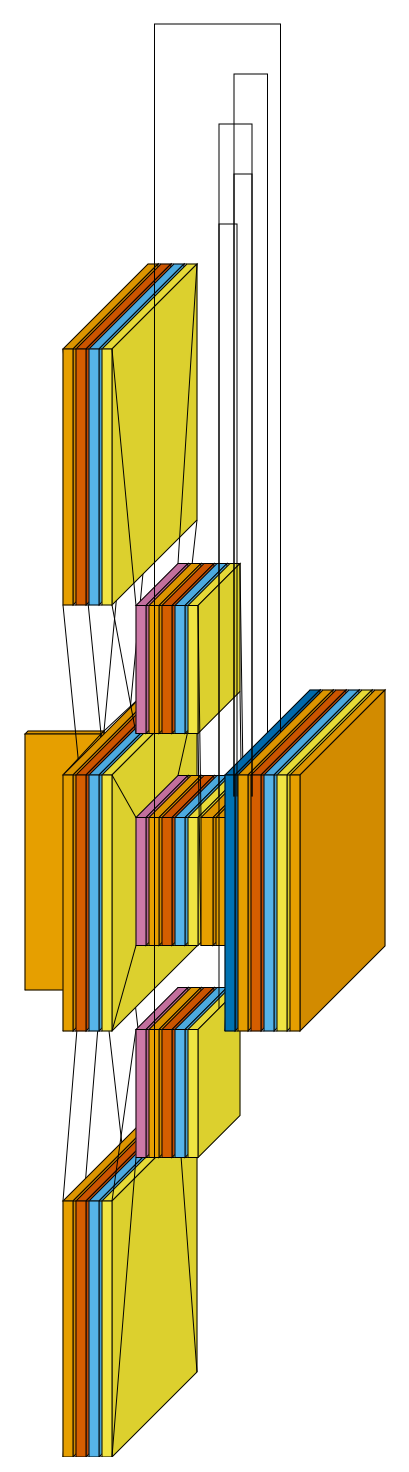

✅ Architecture diagram saved to:
   /content/drive/MyDrive/Data_experiment_shoreline/logs/model_architecture_visualtorch.png
   Final size: 380 × 1443px


In [20]:
# ============================================================
# CELL 9a — Model definition: ConvLSTMUNet (+ MC Dropout), DiceBCELoss,
#   dice_score, MC-dropout uncertainty helpers + parameter summary + visualtorch
#
# Definitions ONLY -- no training here. Training loop DEFINITIONS are in
# Cell 9b, EXECUTION (instantiate + run) is in Cell 9c.
# ============================================================
!pip install visualtorch==1.4.1 -q

import os
from collections import defaultdict
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hidden_ch, kernel_size=3):
        super().__init__()
        self.hidden_ch = hidden_ch
        self.conv = nn.Conv2d(in_ch + hidden_ch, 4 * hidden_ch, kernel_size, padding=kernel_size // 2)

    def forward(self, x, h, c):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        i, f, o, g = torch.chunk(gates, 4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        return h_next, c_next

    def init_hidden(self, batch, H, W, device):
        return (torch.zeros(batch, self.hidden_ch, H, W, device=device),
                torch.zeros(batch, self.hidden_ch, H, W, device=device))


class ConvLSTMUNet(nn.Module):
    """Skip connection pakai enc1 (resolusi H,W), sesuai fix di all_code2.py.
    in_ch dinamis (1 water mask + N static channels dari Cell 8). NEW:
    Dropout2d(mc_dropout_p) setelah enc1/enc2/dec -- dipakai normal saat
    training, dan bisa dipaksa 'on' saat eval lewat enable_mc_dropout() buat
    MC Dropout uncertainty estimation."""

    def __init__(self, in_ch=1, base_ch=16, mc_dropout_p=0.2):
        super().__init__()
        self.mc_dropout_p = mc_dropout_p
        self.enc1 = nn.Sequential(
            nn.Conv2d(in_ch, base_ch, 3, padding=1), nn.BatchNorm2d(base_ch), nn.ReLU(),
            nn.Dropout2d(mc_dropout_p))
        self.enc2 = nn.Sequential(
            nn.Conv2d(base_ch, base_ch * 2, 3, padding=1), nn.BatchNorm2d(base_ch * 2), nn.ReLU(),
            nn.Dropout2d(mc_dropout_p))
        self.pool = nn.MaxPool2d(2)
        self.clstm = ConvLSTMCell(base_ch * 2, base_ch * 2, 3)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)
        self.dec = nn.Sequential(
            nn.Conv2d(base_ch * 3, base_ch, 3, padding=1), nn.BatchNorm2d(base_ch), nn.ReLU(),
            nn.Dropout2d(mc_dropout_p))
        self.head = nn.Conv2d(base_ch, 1, 1)

    def forward(self, x):
        B, T, C, H, W = x.shape
        h, c = None, None
        enc1_last = None
        for t in range(T):
            enc1 = self.enc1(x[:, t])
            enc2 = self.enc2(self.pool(enc1))
            if h is None:
                h, c = self.clstm.init_hidden(B, enc2.shape[2], enc2.shape[3], x.device)
            h, c = self.clstm(enc2, h, c)
            enc1_last = enc1
        up = self.up(h)
        dec = self.dec(torch.cat([up, enc1_last], dim=1))
        return self.head(dec)


class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight

    def forward(self, logit, target):
        prob = torch.sigmoid(logit)
        prob_flat = prob.flatten(1)
        target_flat = target.flatten(1)
        inter = (prob_flat * target_flat).sum(1)
        dice = (2 * inter + 1e-6) / (prob_flat.sum(1) + target_flat.sum(1) + 1e-6)
        dice_loss = 1 - dice.mean()
        bce_loss = self.bce(logit, target)
        return self.bce_weight * bce_loss + (1 - self.bce_weight) * dice_loss


def dice_score(pred, target, eps=1e-6):
    pred, target = pred.flatten(1), target.flatten(1)
    inter = (pred * target).sum(1)
    return (2 * inter + eps) / (pred.sum(1) + target.sum(1) + eps)


# ================== MC DROPOUT uncertainty helpers ==================
def enable_mc_dropout(model):
    """Standard MC Dropout trick (Gal & Ghahramani 2016): keep the model in
    eval() -- BatchNorm uses running stats, no different than normal inference
    -- EXCEPT Dropout2d layers, forced back into train() so they keep sampling
    a fresh mask each forward call."""
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout2d)):
            m.train()
    return model


@torch.no_grad()
def mc_dropout_predict(model, x, n_samples=20):
    """Run n_samples stochastic forward passes (dropout active) and return
    (mean_prob, std_prob). x: (B, T, C, H, W). std_prob is a per-pixel
    epistemic-uncertainty proxy -- high std = model is unsure at that pixel."""
    enable_mc_dropout(model)
    probs = torch.stack([torch.sigmoid(model(x)) for _ in range(n_samples)], dim=0)
    model.eval()  # restore normal (dropout-off) eval mode after sampling
    return probs.mean(0), probs.std(0)


# ================== instantiate for summary/diagram (real training instance is in Cell 9c) ==================
_device_preview = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_IN_CH_preview = IN_CH if "IN_CH" in globals() else 1  # fallback if run before Cell 8
_summary_model = ConvLSTMUNet(in_ch=_IN_CH_preview, base_ch=16).to(_device_preview)


# ================== parameter summary ==================
def print_model_summary(model, in_ch, lookback, patch_size):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print("=" * 60)
    print(f"Model: {model.__class__.__name__} (mc_dropout_p={model.mc_dropout_p})")
    print("=" * 60)
    print(f"{'Sub-module':<20}{'Params':>15}")
    print("-" * 60)
    for name, module in model.named_children():
        n = sum(p.numel() for p in module.parameters())
        print(f"{name:<20}{n:>15,}")
    print("-" * 60)
    print(f"{'Total params':<20}{total:>15,}")
    print(f"{'Trainable params':<20}{trainable:>15,}")
    print(f"Input shape: (B, {lookback}, {in_ch}, {patch_size}, {patch_size})")
    print("=" * 60)


print_model_summary(_summary_model, _IN_CH_preview, LOOKBACK, PATCH_SIZE)

# ================== visualtorch architecture diagram ==================

import os
from collections import defaultdict

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
import visualtorch


try:
    # ---------------------------------------------------------------
    # 1. Buat model khusus untuk visualisasi di CPU
    # ---------------------------------------------------------------
    # visualtorch membuat dummy input sendiri di CPU,
    # jadi model juga harus berada di CPU.
    _viz_model = ConvLSTMUNet(
        in_ch=_IN_CH_preview,
        base_ch=16
    ).to("cpu")

    # Copy weights dari summary model
    _viz_model.load_state_dict(
        _summary_model.state_dict()
    )

    _viz_model.eval()


    # ---------------------------------------------------------------
    # 2. Color map untuk tiap jenis layer
    # ---------------------------------------------------------------
    color_map = defaultdict(dict)

    color_map[nn.Conv2d]["fill"] = "#E69F00"
    color_map[nn.ConvTranspose2d]["fill"] = "#009E73"
    color_map[nn.ReLU]["fill"] = "#56B4E9"
    color_map[nn.MaxPool2d]["fill"] = "#CC79A7"
    color_map[nn.BatchNorm2d]["fill"] = "#D55E00"
    color_map[nn.Upsample]["fill"] = "#0072B2"
    color_map[nn.Dropout2d]["fill"] = "#F0E442"


    # ---------------------------------------------------------------
    # 3. Input shape
    # ---------------------------------------------------------------
    _viz_input_shape = (
        1,
        LOOKBACK,
        _IN_CH_preview,
        PATCH_SIZE,
        PATCH_SIZE
    )


    # ---------------------------------------------------------------
    # 4. Render visualtorch
    # ---------------------------------------------------------------
    # scale_xy dan spacing diperkecil supaya diagram lebih compact.
    img = visualtorch.render(
        _viz_model,
        _viz_input_shape,
        style="flow",
        color_map=color_map,

        # Lebih kecil dari sebelumnya
        scale_xy=1,
        spacing=3,
    )


    # ---------------------------------------------------------------
    # 5. Convert ke PIL Image
    # ---------------------------------------------------------------
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)


    # ---------------------------------------------------------------
    # 6. Auto resize kalau terlalu lebar
    # ---------------------------------------------------------------
    # Tidak mengubah aspect ratio.
    # Jadi gambar tidak akan gepeng.
    MAX_WIDTH = 2200

    if img.width > MAX_WIDTH:
        ratio = MAX_WIDTH / img.width

        new_width = MAX_WIDTH
        new_height = int(img.height * ratio)

        img = img.resize(
            (new_width, new_height),
            Image.Resampling.LANCZOS
        )


    # ---------------------------------------------------------------
    # 7. Save
    # ---------------------------------------------------------------
    output_path = os.path.join(
        LOG_DIR,
        "model_architecture_visualtorch.png"
    )

    dpi = 150

    plt.figure(
        figsize=(
            img.width / dpi,
            img.height / dpi
        ),
        dpi=dpi
    )

    plt.imshow(img)
    plt.axis("off")

    plt.tight_layout(
        pad=0
    )

    plt.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
        pad_inches=0.05
    )

    plt.show()

    print(f"✅ Architecture diagram saved to:")
    print(f"   {output_path}")
    print(f"   Final size: {img.width} × {img.height}px")


except Exception as e:
    print(f"⚠️ visualtorch gagal render: {e}")
    print("   Fallback -- print(model) biasa:")
    print(_summary_model)

In [24]:
# ============================================================
# CELL 9b — Training loop definitions: sampling_prob, multistep_forward,
#   train_loop. DEFINITIONS ONLY -- no execution (see Cell 9c).
#
# train_loop now logs to TensorBoard every epoch (loss/train, dice/train,
# dice/test, scheduled_sampling/prob) plus a text event whenever a checkpoint
# is saved (best or periodic), via a SummaryWriter passed in from Cell 9c.
# ============================================================
import os
import torch

EPOCHS = 500
BATCH_SIZE = 4
CKPT_EVERY = 10          # save a periodic checkpoint every N epochs
SS_MAX_PROB = 0.5        # scheduled-sampling probability cap
SS_RAMP_EPOCHS = 250     # epochs to linearly ramp sampling prob 0 -> SS_MAX_PROB


def sampling_prob(epoch, max_prob=SS_MAX_PROB, ramp_epochs=SS_RAMP_EPOCHS):
    if ramp_epochs <= 0:
        return max_prob
    return max_prob * min(epoch / ramp_epochs, 1.0)


def multistep_forward(model, x_window, y_multi, criterion, epoch, train=True):
    """Roll the model forward y_multi.shape[1] steps. At each step, feed back
    either the model's own (detached) prediction or ground truth for the MASK
    channel (index 0), chosen per sample by a coin flip at sampling_prob(epoch).
    STATIC channels (index 1+: elevation/slope/etc from Cell 8) don't change
    over time, so they're carried forward unchanged from the window's last
    frame, not regenerated."""
    B = x_window.shape[0]
    window = x_window
    static_part = window[:, -1, 1:]  # (B, IN_CH-1, H, W) -- constant across rollout
    step_losses = []
    first_pred = None
    prob = sampling_prob(epoch) if train else 0.0  # eval always teacher-forced

    for step in range(y_multi.shape[1]):
        logit = model(window)
        target = y_multi[:, step]
        step_losses.append(criterion(logit, target))
        if step == 0:
            first_pred = logit

        with torch.no_grad():
            pred_mask = (torch.sigmoid(logit) > 0.5).float()
            use_pred = (torch.rand(B, device=window.device) < prob).float().view(B, 1, 1, 1)
            next_mask = (use_pred * pred_mask + (1 - use_pred) * target).detach()
            next_frame = (torch.cat([next_mask, static_part], dim=1)
                          if static_part.shape[1] > 0 else next_mask)

        if step < y_multi.shape[1] - 1:
            window = torch.cat([window[:, 1:], next_frame.unsqueeze(1)], dim=1)

    loss = torch.stack(step_losses).mean()
    return loss, first_pred

def eval_dice_batched(model, X, y, criterion, epoch, batch_size):
    dices = []
    for i in range(0, len(X), batch_size):
        xb, yb = X[i:i + batch_size], y[i:i + batch_size]
        _, logit = multistep_forward(model, xb, yb, criterion, epoch, train=False)
        pred = (torch.sigmoid(logit) > 0.5).float()
        dices.append(dice_score(pred, yb[:, 0]))
    return torch.cat(dices).mean().item()

def train_loop(model, optimizer, criterion, X_tr, y_tr, X_te, y_te, ckpt_dir, writer,
               epochs=EPOCHS, batch_size=BATCH_SIZE, ckpt_every=CKPT_EVERY, logger=None):
    """Full training loop -- DEFINED here, CALLED in Cell 9c. `writer` is a
    torch.utils.tensorboard.SummaryWriter created in Cell 9c."""
    history = {"train_loss": [], "train_dice": [], "test_dice": [], "sampling_prob": []}
    n = len(X_tr)
    best_test_dice = -1.0

    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            optimizer.zero_grad()
            loss, _ = multistep_forward(model, xb, yb, criterion, epoch, train=True)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        epoch_loss /= n

        model.eval()
        with torch.no_grad():
            tr_dice = eval_dice_batched(model, X_tr, y_tr, criterion, epoch, batch_size)
            te_dice = eval_dice_batched(model, X_te, y_te, criterion, epoch, batch_size)

        history["train_loss"].append(epoch_loss)
        history["train_dice"].append(tr_dice)
        history["test_dice"].append(te_dice)
        history["sampling_prob"].append(sampling_prob(epoch))

        # ---------- TensorBoard: loss/dice/sampling_prob every epoch ----------
        writer.add_scalar("loss/train", epoch_loss, epoch)
        writer.add_scalar("dice/train", tr_dice, epoch)
        writer.add_scalar("dice/test", te_dice, epoch)
        writer.add_scalar("scheduled_sampling/prob", sampling_prob(epoch), epoch)

        if te_dice > best_test_dice:
            best_test_dice = te_dice
            torch.save(model.state_dict(), os.path.join(ckpt_dir, "best.pth"))
            writer.add_text("checkpoint", f"epoch {epoch}: NEW BEST test_dice={te_dice:.4f} -> best.pth", epoch)

        if epoch % ckpt_every == 0 or epoch == epochs - 1:
            torch.save(model.state_dict(), os.path.join(ckpt_dir, f"ep{epoch:04d}.pth"))
            writer.add_text("checkpoint", f"epoch {epoch}: periodic checkpoint -> ep{epoch:04d}.pth", epoch)

        if (epoch % 20 == 0 or epoch == epochs - 1) and logger is not None:
            logger.info(f"Epoch {epoch:3d} | loss={epoch_loss:.4f} | tr={tr_dice:.4f} | te={te_dice:.4f} "
                        f"| ss_prob={sampling_prob(epoch):.2f} | best_te={best_test_dice:.4f}")

    torch.save(model.state_dict(), os.path.join(ckpt_dir, "last.pth"))
    writer.add_text("checkpoint", f"epoch {epochs - 1}: FINAL -> last.pth", epochs - 1)
    return history, best_test_dice

In [ ]:
# ============================================================
# CELL 9c — EXECUTE: instantiate model/optimizer, resume-from-Drive if the
#   session dropped, run train_loop (Cell 9b), FP16 compression, MC-dropout
#   uncertainty demo, matplotlib plots. Run Cell 9a (patched) and 9b first.
#
# TensorBoard: logs are written to Drive (see TB_LOG_DIR below) for viewing
# via your OWN linked TensorBoard instance -- no inline Colab %tensorboard
# magic here.
# ============================================================
import os
import json
import logging
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from datetime import datetime
from torch.utils.tensorboard import SummaryWriter

torch.manual_seed(42)

# ---------- resume from Drive if session dropped ----------
FINAL_DATA_DIR = "/content/drive/MyDrive/Data_experiment_shoreline/final_data"
if "X_train" not in globals():
    print("X_train tidak ada di memory -- reload dari Drive final_data/ ...")
    _tz = np.load(os.path.join(FINAL_DATA_DIR, "tensors.npz"))
    with open(os.path.join(FINAL_DATA_DIR, "params.json")) as f:
        _params = json.load(f)
    IN_CH = _params["IN_CH"]
    _X, _y, _tr, _te = _tz["X"], _tz["y"], _tz["tr"], _tz["te"]
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_train = torch.from_numpy(_X[_tr]).float().to(device)
    y_train = torch.from_numpy(_y[_tr]).float().to(device)
    X_test  = torch.from_numpy(_X[_te]).float().to(device)
    y_test  = torch.from_numpy(_y[_te]).float().to(device)
    print(f"✓ Reload dari Drive: IN_CH={IN_CH}, train={len(_tr)}, test={len(_te)}")
else:
    print(f"Pakai X_train/X_test yang sudah ada di memory (IN_CH={IN_CH}).")

model = ConvLSTMUNet(in_ch=IN_CH, base_ch=16, mc_dropout_p=0.2).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,} (in_ch={IN_CH})")
criterion = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

logger = logging.getLogger(f"train_{run_id}")
logger.setLevel(logging.INFO)
logger.handlers.clear()
fh = logging.FileHandler(os.path.join(LOG_DIR, f"train_{run_id}.log"))
fh.setFormatter(logging.Formatter("%(asctime)s | %(message)s", datefmt="%H:%M:%S"))
logger.addHandler(fh)
logger.addHandler(logging.StreamHandler())

CKPT_DIR = os.path.join(MODEL_DIR, f"checkpoints_{run_id}")
os.makedirs(CKPT_DIR, exist_ok=True)

TB_ROOT = os.path.join(LOG_DIR, "tensorboard")
TB_LOG_DIR = os.path.join(TB_ROOT, run_id)
os.makedirs(TB_LOG_DIR, exist_ok=True)
writer = SummaryWriter(log_dir=TB_LOG_DIR)
print(f"TensorBoard log dir: {TB_LOG_DIR}")
print(f"(parent folder, to compare multiple runs: {TB_ROOT})")

# ---------- inline TensorBoard -- opens a live view you can watch during training ----------
%load_ext tensorboard
%tensorboard --logdir $TB_ROOT

# ---------- persistence baseline ----------
persist_pred = X_test[:, -1, 0:1]  # channel 0 = water mask
dice_baseline = dice_score(persist_pred, y_test[:, 0]).mean().item()
print(f"Persistence baseline Dice (next-step): {dice_baseline:.4f}")
writer.add_scalar("dice/persistence_baseline", dice_baseline, 0)

# ---------- RUN ----------
history, best_test_dice = train_loop(model, optimizer, criterion, X_train, y_train, X_test, y_test,
                                      CKPT_DIR, writer, logger=logger)
writer.close()

np.savez_compressed(os.path.join(LOG_DIR, f"history_{run_id}.npz"), **history)
print(f"\n✓ Checkpoints: {CKPT_DIR}")
print(f"✓ History: {os.path.join(LOG_DIR, f'history_{run_id}.npz')}")
print(f"✓ TensorBoard logs: {TB_LOG_DIR}")

# ============================================================
# NEW -- POST-TRAINING COMPRESSION: FP16 half-precision (see cell docstring
# above for why INT8 static quantization is skipped rather than shipped broken)
# ============================================================
fp16_model = ConvLSTMUNet(in_ch=IN_CH, base_ch=16, mc_dropout_p=0.0)
fp16_model.load_state_dict(torch.load(os.path.join(CKPT_DIR, "best.pth"), map_location="cpu"))
fp16_model = fp16_model.half().to(device)
fp16_model.eval()

fp16_path = os.path.join(CKPT_DIR, "best_fp16.pth")
torch.save(fp16_model.state_dict(), fp16_path)

_orig_size = os.path.getsize(os.path.join(CKPT_DIR, "best.pth")) / 1e6
_fp16_size = os.path.getsize(fp16_path) / 1e6
print(f"\n✓ FP16 checkpoint: {fp16_path}")
print(f"  fp32 best.pth: {_orig_size:.2f} MB -> fp16: {_fp16_size:.2f} MB "
      f"({100 * (1 - _fp16_size / _orig_size):.1f}% smaller)")
print("  Catatan: fp16_model cuma buat inference di GPU (x.half()) -- CPU half-precision")
print("  sering gak didukung/lambat. INT8 static quant proper butuh rework")
print("  ConvLSTMCell's quant boundaries -- di luar scope patch ini.")

# ============================================================
# NEW -- MC DROPOUT uncertainty demo (1 sample, mean + std map)
# ============================================================
_sample_idx = 0
_x_sample = X_test[_sample_idx: _sample_idx + 1]
mean_prob, std_prob = mc_dropout_predict(model, _x_sample, n_samples=20)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(y_test[_sample_idx, 0].cpu().numpy(), cmap="Blues")
axes[0].set_title("Ground truth (next-step)")
axes[1].imshow(mean_prob[0, 0].cpu().numpy(), cmap="Blues", vmin=0, vmax=1)
axes[1].set_title(f"MC Dropout mean prob (n=20)")
im2 = axes[2].imshow(std_prob[0, 0].cpu().numpy(), cmap="inferno")
axes[2].set_title("MC Dropout std (epistemic uncertainty)")
fig.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, f"mc_dropout_uncertainty_{run_id}.png"), dpi=120)
plt.show()
print(f"Uncertainty map (std) range: [{std_prob.min().item():.4f}, {std_prob.max().item():.4f}] "
      f"-- pixel dgn std tinggi = model paling gak yakin di situ (biasanya di tepi garis pantai).")

# ---------- matplotlib plots (complementary to TensorBoard, saved as PNG) ----------
epochs_range = range(len(history["train_loss"]))
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(epochs_range, history["train_loss"], color="tab:blue")
axes[0].set_title("Training Loss (multi-step Dice+BCE)"); axes[0].set_xlabel("epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, history["train_dice"], label="train", color="tab:green")
axes[1].plot(epochs_range, history["test_dice"], label="test", color="tab:orange")
axes[1].axhline(dice_baseline, color="red", ls="--", label=f"persistence ({dice_baseline:.3f})")
axes[1].set_title("Dice Score (next-step)"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
gap = np.array(history["train_dice"]) - np.array(history["test_dice"])
axes[2].plot(epochs_range, gap, color="tab:red")
axes[2].axhline(0.15, color="gray", ls=":", label="overfit threshold")
axes[2].set_title("Train-Test Gap"); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(LOG_DIR, f"training_{run_id}.png"), dpi=120)
plt.show()

final_gap = history["train_dice"][-1] - history["test_dice"][-1]
print(f"\n{'='*50}")
print(f"Final train Dice: {history['train_dice'][-1]:.4f}")
print(f"Final test Dice:  {history['test_dice'][-1]:.4f}")
print(f"Best test Dice:   {best_test_dice:.4f} (checkpoint: {CKPT_DIR}/best.pth)")
print(f"Persistence:      {dice_baseline:.4f}")
print(f"Train-test gap:   {final_gap:.4f} {'⚠ overfit' if final_gap > 0.15 else '✓ wajar'}")
print(f"Model {'✓ MENGALAHKAN' if history['test_dice'][-1] > dice_baseline else '✗ KALAH DARI'} persistence")
print(f"{'='*50}")
print("\n✓ Training selesai. Checkpoint (periodik + best + last + fp16) di", CKPT_DIR)

Pakai X_train/X_test yang sudah ada di memory (IN_CH=7).
Parameters: 86,593 (in_ch=7)
TensorBoard log dir: /content/drive/MyDrive/Data_experiment_shoreline/logs/tensorboard/20260730_070044
(parent folder, to compare multiple runs: /content/drive/MyDrive/Data_experiment_shoreline/logs/tensorboard)
The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 21017), started 0:05:42 ago. (Use '!kill 21017' to kill it.)

<IPython.core.display.Javascript object>

Persistence baseline Dice (next-step): 0.9472


Epoch   0 | loss=0.5647 | tr=0.4441 | te=0.8836 | ss_prob=0.00 | best_te=0.8836
INFO:train_20260730_070044:Epoch   0 | loss=0.5647 | tr=0.4441 | te=0.8836 | ss_prob=0.00 | best_te=0.8836
Epoch  20 | loss=0.4614 | tr=0.6426 | te=0.9589 | ss_prob=0.04 | best_te=0.9651
INFO:train_20260730_070044:Epoch  20 | loss=0.4614 | tr=0.6426 | te=0.9589 | ss_prob=0.04 | best_te=0.9651
Epoch  40 | loss=0.4383 | tr=0.6398 | te=0.9658 | ss_prob=0.08 | best_te=0.9660
INFO:train_20260730_070044:Epoch  40 | loss=0.4383 | tr=0.6398 | te=0.9658 | ss_prob=0.08 | best_te=0.9660
Epoch  60 | loss=0.4418 | tr=0.6477 | te=0.9644 | ss_prob=0.12 | best_te=0.9660
INFO:train_20260730_070044:Epoch  60 | loss=0.4418 | tr=0.6477 | te=0.9644 | ss_prob=0.12 | best_te=0.9660
Epoch  80 | loss=0.4401 | tr=0.6211 | te=0.9651 | ss_prob=0.16 | best_te=0.9660
INFO:train_20260730_070044:Epoch  80 | loss=0.4401 | tr=0.6211 | te=0.9651 | ss_prob=0.16 | best_te=0.9660
Epoch 100 | loss=0.4398 | tr=0.6408 | te=0.9648 | ss_prob=0.20 | 

In [ ]:
# ============================================================
# CELL 7 — Rollout + Transect EPR + LRR comparison + collapse diagnostic
#
# Reuses the plotting/analysis functions from notebooks/all_code2.py
# (full_analysis_plot, diagnose_rollout_collapse, compute_lrr_and_compare, and
# their contour/transect helpers) essentially unchanged. The only real change:
# those functions originally sorted frames via seq_index(year, season) assuming
# a fixed 3-season/year grid. Since combined_masks is keyed by continuous time
# t (Cell 4), sorting is just sorted(frames.keys()) and next_n_labels steps by
# a fixed ~1/3-year cadence (Sentinel's, since that's what's used going forward).
# ============================================================
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import contextily as ctx
from skimage import measure
from matplotlib.lines import Line2D
from matplotlib import cm, colors as mcolors
from shapely.geometry import LineString, Point
from scipy.interpolate import splprep, splev
from pyproj import Transformer

# ---------- load best checkpoint (avoids depending on in-memory `model` state) ----------
EVAL_CKPT = os.path.join(CKPT_DIR, "best.pth")
eval_model = ConvLSTMUNet(in_ch=1, base_ch=16).to(device)
eval_model.load_state_dict(torch.load(EVAL_CKPT, map_location=device))
eval_model.eval()
print(f"Eval model loaded: {EVAL_CKPT}")

# ---------- AOI_CONFIG: lon/lat per AOI, preferring Sentinel manifest ----------
AOI_CONFIG = {}
for nama in all_aoi:
    src = manifest_sentinel["aoi"].get(nama) or manifest_landsat["aoi"].get(nama)
    if src is None:
        continue
    AOI_CONFIG[nama] = {"coord": [src["lon"], src["lat"]], "note": ""}

STEP_YEARS = 1 / 3  # cadence used for projecting future labels (Sentinel S1/S2/S3)


def rollout_forecast(model, seed_frames, n_steps):
    window = list(seed_frames)
    predictions = []
    with torch.no_grad():
        for _ in range(n_steps):
            stacked = np.stack([f[np.newaxis] for f in window])
            x = torch.from_numpy(stacked[np.newaxis]).float().to(device)
            prob = torch.sigmoid(model(x)).cpu().numpy()[0, 0]
            pred = (prob > 0.5).astype(np.float32)
            predictions.append(pred)
            window = window[1:] + [pred]
    return predictions


def next_n_t(last_t, n, step=STEP_YEARS):
    return [last_t + step * (i + 1) for i in range(n)]


def patch_bounds(lon, lat):
    half_m = PATCH_SIZE * SCALE_M / 2
    dlat = half_m / 111320
    dlon = half_m / (111320 * np.cos(np.radians(lat)))
    return [[lat - dlat, lon - dlon], [lat + dlat, lon + dlon]]


def pixel_to_lonlat(row, col, lon_c, lat_c):
    bounds = patch_bounds(lon_c, lat_c)
    south, west = bounds[0]
    north, east = bounds[1]
    lat = north - (row / (PATCH_SIZE - 1)) * (north - south)
    lon = west + (col / (PATCH_SIZE - 1)) * (east - west)
    return lon, lat


def smooth_contour_spline(contour, smoothing=2.0, n_points=300):
    if len(contour) < 4:
        return contour
    y, x = contour[:, 0], contour[:, 1]
    try:
        tck, u = splprep([x, y], s=smoothing, per=False)
        u_fine = np.linspace(0, 1, n_points)
        x_fine, y_fine = splev(u_fine, tck)
        return np.column_stack([y_fine, x_fine])
    except Exception:
        return contour


def extract_main_contour(mask, use_spline=True, spline_smoothing=2.0):
    contours = measure.find_contours(mask, 0.5)
    if not contours:
        return None
    main = max(contours, key=len)
    if use_spline:
        main = smooth_contour_spline(main, smoothing=spline_smoothing)
    return main


def add_scalebar(ax, lat_c, length_m=200):
    deg_per_m = 1 / (111320 * np.cos(np.radians(lat_c)))
    bar_len_deg = length_m * deg_per_m
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    x0 = xlim[0] + (xlim[1] - xlim[0]) * 0.05
    y0 = ylim[0] + (ylim[1] - ylim[0]) * 0.05
    ax.plot([x0, x0 + bar_len_deg], [y0, y0], color="black", lw=3, solid_capstyle="butt", zorder=10)
    ax.plot([x0, x0], [y0, y0 + (ylim[1] - ylim[0]) * 0.01], color="black", lw=2, zorder=10)
    ax.plot([x0 + bar_len_deg, x0 + bar_len_deg], [y0, y0 + (ylim[1] - ylim[0]) * 0.01], color="black", lw=2, zorder=10)
    ax.text(x0 + bar_len_deg / 2, y0 + (ylim[1] - ylim[0]) * 0.02, f"{length_m} m",
            ha="center", fontsize=8, fontweight="bold", zorder=10)


def make_transects(contour_px, n_transects=40, length_px=8):
    coords_xy = contour_px[:, ::-1]
    line = LineString(coords_xy)
    total_len = line.length
    positions = np.linspace(0.08, 0.92, n_transects) * total_len
    transects = []
    for pos in positions:
        pt = line.interpolate(pos)
        pt2 = line.interpolate(min(pos + 0.5, total_len))
        dx, dy = pt2.x - pt.x, pt2.y - pt.y
        norm = np.hypot(dx, dy) + 1e-9
        nx, ny = -dy / norm, dx / norm
        p1 = (pt.x - nx * length_px, pt.y - ny * length_px)
        p2 = (pt.x + nx * length_px, pt.y + ny * length_px)
        transects.append((p1, p2))
    return transects


def transect_intersect(transects, contour_px):
    coords_xy = contour_px[:, ::-1]
    shoreline = LineString(coords_xy)
    pts = []
    for p1, p2 in transects:
        t = LineString([p1, p2])
        inter = t.intersection(shoreline)
        if inter.is_empty:
            pts.append(None)
        elif inter.geom_type == "Point":
            pts.append((inter.x, inter.y))
        else:
            pts.append((list(inter.geoms)[0].x, list(inter.geoms)[0].y))
    return pts


def compute_epr(transects, contour_first, contour_last, time_years, px_to_m=SCALE_M):
    pts_first = transect_intersect(transects, contour_first)
    pts_last = transect_intersect(transects, contour_last)
    eprs = []
    for (p1, p2), pf, pl in zip(transects, pts_first, pts_last):
        if pf is None or pl is None:
            eprs.append(None)
            continue
        disp = np.array([pl[0] - pf[0], pl[1] - pf[1]])
        direction = np.array([p2[0] - p1[0], p2[1] - p1[1]])
        direction = direction / (np.linalg.norm(direction) + 1e-9)
        signed_dist_px = np.dot(disp, direction)
        eprs.append(signed_dist_px * px_to_m / (time_years + 1e-9))
    return eprs


# ============================================================
# full_analysis_plot — rollout + transect EPR map (adapted for t-keyed frames)
# ============================================================
def full_analysis_plot(nama, masks, model, target_t=None, n_transects=40, transect_length_px=8):
    lon_c, lat_c = AOI_CONFIG[nama]["coord"]
    frames = masks[nama]
    ts_sorted = sorted(frames.keys())
    real_frames = [frames[t] for t in ts_sorted]
    last_t = ts_sorted[-1]
    if target_t is None:
        target_t = last_t + 5  # ~5 years ahead by default

    n_steps = max(int(round((target_t - last_t) / STEP_YEARS)), 0)
    labels_future = next_n_t(last_t, n_steps) if n_steps > 0 else []
    preds_future = rollout_forecast(model, real_frames[-LOOKBACK:], len(labels_future))

    all_frames = real_frames + preds_future
    all_labels = ts_sorted + labels_future
    n_real = len(real_frames)

    contours_px = [extract_main_contour(f, use_spline=True, spline_smoothing=2.0) for f in all_frames]

    fig, ax = plt.subplots(figsize=(14, 14))
    bounds = patch_bounds(lon_c, lat_c)
    ax.set_xlim(bounds[0][1], bounds[1][1])
    ax.set_ylim(bounds[0][0], bounds[1][0])
    try:
        ctx.add_basemap(ax, crs="EPSG:4326", source=ctx.providers.Esri.WorldImagery, zoom=16)
    except Exception as e:
        print(f"[{nama}] basemap gagal: {e}")

    cmap_real = cm.viridis
    for i in range(n_real):
        if contours_px[i] is None:
            continue
        frac = i / max(n_real - 1, 1)
        lons, lats = zip(*[pixel_to_lonlat(r, c, lon_c, lat_c) for r, c in contours_px[i]])
        ax.plot(lons, lats, color=cmap_real(frac), lw=1.6, alpha=0.9)

    cmap_proj = cm.Reds
    for j, i in enumerate(range(n_real, len(all_frames))):
        if contours_px[i] is None:
            continue
        frac = 1 - (j / max(len(preds_future), 1)) * 0.7
        alpha = max(0.25, 1 - (j / max(len(preds_future), 1)) * 0.75)
        lons, lats = zip(*[pixel_to_lonlat(r, c, lon_c, lat_c) for r, c in contours_px[i]])
        ax.plot(lons, lats, color=cmap_proj(frac), lw=1.4, ls="--", alpha=alpha)

    ref_idx = next(i for i in reversed(range(n_real)) if contours_px[i] is not None)
    first_idx = next(i for i in range(n_real) if contours_px[i] is not None)
    transects_px = make_transects(contours_px[ref_idx], n_transects=n_transects, length_px=transect_length_px)
    time_years = max(all_labels[ref_idx] - all_labels[first_idx], 1e-3)

    eprs = compute_epr(transects_px, contours_px[first_idx], contours_px[ref_idx], time_years)
    eprs_valid = [e for e in eprs if e is not None]
    vmax = max(abs(min(eprs_valid, default=0)), abs(max(eprs_valid, default=0)), 0.1)
    norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
    cmap_epr = cm.RdBu

    for (p1, p2), epr in zip(transects_px, eprs):
        lon1, lat1 = pixel_to_lonlat(p1[1], p1[0], lon_c, lat_c)
        lon2, lat2 = pixel_to_lonlat(p2[1], p2[0], lon_c, lat_c)
        color = cmap_epr(norm(epr)) if epr is not None else "gray"
        ax.plot([lon1, lon2], [lat1, lat2], color=color, lw=1.2, alpha=0.85)

    sm = cm.ScalarMappable(cmap=cmap_epr, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("EPR (m/tahun) → biru: akresi | merah: erosi", fontsize=8)
    add_scalebar(ax, lat_c, length_m=200)

    legend_elems = [
        Line2D([0], [0], color=cmap_real(0.1), lw=2, label=f"t={ts_sorted[0]:.2f} (awal)"),
        Line2D([0], [0], color=cmap_real(0.9), lw=2, label=f"t={ts_sorted[-1]:.2f} (terbaru, real)"),
        Line2D([0], [0], color=cmap_proj(0.8), lw=2, ls="--", label=f"rollout t≈{target_t:.1f} (proyeksi)"),
    ]
    ax.legend(handles=legend_elems, loc="upper left", fontsize=7, bbox_to_anchor=(0, -0.03), ncol=1, frameon=True)
    ax.set_title(f"{nama} — ConvLSTM-UNet (Landsat+Sentinel) | Shoreline + Transect EPR s/d t≈{target_t:.1f}", fontsize=11)
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

    plt.tight_layout()
    plt.savefig(os.path.join(LOG_DIR, f"full_analysis_{nama}_{run_id}.png"), dpi=150, bbox_inches="tight")
    plt.show()
    return pd.DataFrame({"transect": range(len(eprs)), "epr_m_per_yr": eprs})


# ============================================================
# diagnose_rollout_collapse — is the model actually "moving", or copy-pasting?
# ============================================================
def diagnose_rollout_collapse(nama, masks, model, target_t=None):
    frames = masks[nama]
    ts_sorted = sorted(frames.keys())
    last_t = ts_sorted[-1]
    if target_t is None:
        target_t = last_t + 5
    n_steps = max(int(round((target_t - last_t) / STEP_YEARS)), 0)
    seed = [frames[t] for t in ts_sorted[-LOOKBACK:]]
    preds_future = rollout_forecast(model, seed, n_steps) if n_steps > 0 else []

    def pixel_change(m1, m2):
        m1b, m2b = (m1 > 0.5), (m2 > 0.5)
        union = np.logical_or(m1b, m2b).sum()
        diff = np.logical_xor(m1b, m2b).sum()
        return diff / max(union, 1)

    all_masks = seed + list(preds_future)
    changes = [pixel_change(all_masks[i], all_masks[i + 1]) for i in range(len(all_masks) - 1)]
    n_seed_transitions = len(seed) - 1

    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(range(1, len(changes) + 1), changes, marker="o", markersize=4)
    if n_seed_transitions > 0:
        ax.axvline(n_seed_transitions, color="gray", linestyle=":", label="mulai rollout (bukan GT lagi)")
    ax.set_xlabel("Langkah ke-n"); ax.set_ylabel("Fraksi area berubah")
    ax.set_title(f"[{nama}] Diagnostik rollout collapse")
    ax.legend(); plt.show()

    avg_seed = np.mean(changes[:n_seed_transitions]) if n_seed_transitions > 0 else None
    avg_rollout = np.mean(changes[n_seed_transitions:]) if len(changes) > n_seed_transitions else None
    print(f"Rata2 perubahan/langkah GT (seed)  : {avg_seed}")
    print(f"Rata2 perubahan/langkah ROLLOUT     : {avg_rollout}")
    if avg_seed and avg_rollout is not None and avg_rollout < avg_seed * 0.3:
        print("⚠️  Rollout jauh lebih 'diam' dibanding GT historis -- indikasi persistence collapse.")
    return changes


# ============================================================
# LRR (linear regression rate) baseline vs model rollout, per transect
# ============================================================
_to_merc = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True).transform


def contour_to_xy(mask_arr, lon_c, lat_c, spline_smoothing=0.5):
    c = extract_main_contour(mask_arr, use_spline=True, spline_smoothing=spline_smoothing)
    if c is None:
        return None
    lonlats = [pixel_to_lonlat(r, cc, lon_c, lat_c) for r, cc in c]
    return [_to_merc(lon, lat) for lon, lat in lonlats]


def build_transects(baseline_xy, spacing_m=50, length_m=800):
    line = LineString(baseline_xy)
    total_len = line.length
    n = int(total_len // spacing_m)
    transects = []
    for i in range(1, n):
        d = i * spacing_m
        p = line.interpolate(d)
        p_before = line.interpolate(max(d - 1, 0))
        p_after = line.interpolate(min(d + 1, total_len))
        dx, dy = p_after.x - p_before.x, p_after.y - p_before.y
        norm = (dx ** 2 + dy ** 2) ** 0.5
        if norm == 0:
            continue
        nx, ny = -dy / norm, dx / norm
        t_line = LineString([
            (p.x - nx * length_m / 2, p.y - ny * length_m / 2),
            (p.x + nx * length_m / 2, p.y + ny * length_m / 2),
        ])
        transects.append({"id": i, "origin": (p.x, p.y), "dir": (nx, ny), "line": t_line})
    return transects


def shoreline_position_on_transects(contour_xy, transects):
    result = {t["id"]: None for t in transects}
    if contour_xy is None or len(contour_xy) < 2:
        return result
    shore = LineString(contour_xy)
    for t in transects:
        inter = shore.intersection(t["line"])
        if inter.is_empty:
            continue
        pts = list(inter.geoms) if inter.geom_type == "MultiPoint" else [inter]
        pts = [p for p in pts if isinstance(p, Point)]
        if not pts:
            continue
        ox, oy = t["origin"]
        closest = min(pts, key=lambda p: (p.x - ox) ** 2 + (p.y - oy) ** 2)
        nx, ny = t["dir"]
        signed_dist = (closest.x - ox) * nx + (closest.y - oy) * ny
        result[t["id"]] = signed_dist
    return result


def compute_lrr_and_compare(nama, masks, model, target_t=None, spacing_m=50, transect_len_m=800,
                             spline_smoothing=0.5):
    frames = masks[nama]
    ts_sorted = sorted(frames.keys())
    last_t = ts_sorted[-1]
    if target_t is None:
        target_t = last_t + 5
    lon_c, lat_c = AOI_CONFIG[nama]["coord"]

    gt_contours = {t: contour_to_xy(frames[t], lon_c, lat_c, spline_smoothing) for t in ts_sorted}
    gt_contours = {t: xy for t, xy in gt_contours.items() if xy}

    baseline_t = min(gt_contours.keys())
    baseline_xy = gt_contours[baseline_t]
    transects = build_transects(baseline_xy, spacing_m=spacing_m, length_m=transect_len_m)
    print(f"[{nama}] {len(transects)} transects | spacing {spacing_m}m | baseline t={baseline_t:.2f}")

    per_transect_series = {t["id"]: [] for t in transects}
    for t_year, xy in gt_contours.items():
        pos = shoreline_position_on_transects(xy, transects)
        for tid, dist in pos.items():
            if dist is not None:
                per_transect_series[tid].append((t_year, dist))

    lrr_results = {}
    for tid, series in per_transect_series.items():
        if len(series) < 2:
            lrr_results[tid] = None
            continue
        years = np.array([p[0] for p in series])
        dists = np.array([p[1] for p in series])
        slope, intercept = np.polyfit(years, dists, 1)
        lrr_results[tid] = {"rate_m_per_year": slope, "pred_dist": slope * target_t + intercept, "n_obs": len(series)}

    n_steps = max(int(round((target_t - last_t) / STEP_YEARS)), 0)
    seed = [frames[t] for t in ts_sorted[-LOOKBACK:]]
    future_labels = next_n_t(last_t, n_steps) if n_steps > 0 else []
    future_preds = rollout_forecast(model, seed, n_steps) if n_steps > 0 else []

    model_dist = {}
    if future_labels:
        idx = int(np.argmin([abs(t - target_t) for t in future_labels]))
        xy = contour_to_xy(future_preds[idx], lon_c, lat_c, spline_smoothing)
        model_dist = shoreline_position_on_transects(xy, transects)
        print(f"Posisi model diambil dari rollout t={future_labels[idx]:.2f}")

    tids = [t["id"] for t in transects]
    lrr_vals = [lrr_results[tid]["pred_dist"] if lrr_results[tid] else np.nan for tid in tids]
    model_vals = [model_dist.get(tid, np.nan) for tid in tids]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(tids, lrr_vals, label="Proyeksi LRR (statistik klasik)", marker="o", markersize=3)
    ax.plot(tids, model_vals, label="Proyeksi model (rollout)", marker="x", markersize=3)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_xlabel("ID Transect"); ax.set_ylabel(f"Jarak signed dari baseline (m) @ t≈{target_t:.1f}")
    ax.set_title(f"[{nama}] Model vs LRR — proyeksi t≈{target_t:.1f}")
    ax.legend(); plt.show()

    diffs = np.array(lrr_vals) - np.array(model_vals)
    valid = ~np.isnan(diffs)
    if valid.sum() > 0:
        rates = [lrr_results[tid]["rate_m_per_year"] for tid in tids if lrr_results[tid]]
        print(f"Rata2 |selisih model - LRR|: {np.nanmean(np.abs(diffs)):.1f} m ({valid.sum()} transect valid)")
        print(f"Laju perubahan LRR rata2: {np.mean(rates):.2f} m/tahun")

    return transects, lrr_results, model_dist


# ---------- jalankan untuk semua AOI ----------
all_epr = {}
for nama in AOI_CONFIG:
    if nama not in combined_masks:
        continue
    print(f"\n=== {nama} ===")
    epr_df = full_analysis_plot(nama, combined_masks, eval_model, n_transects=70, transect_length_px=3)
    all_epr[nama] = epr_df
    print(epr_df.describe())
    diagnose_rollout_collapse(nama, combined_masks, eval_model)
    compute_lrr_and_compare(nama, combined_masks, eval_model)
